# Phase 2 · 9단원 — 모델 평가

> **모델이 정확도 95%를 냈습니다. 좋은 걸까요?**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/09-model-evaluation>
- 예상 시간: 90분 · 선수 지식: Phase 2 1~8단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **훈련/검증/테스트** 분할과 **K-겹 교차검증**(층화 포함)을 밑바닥부터 만듭니다.
2. **혼동 행렬**에서 정확도·정밀도·재현율·F1을 뽑고, **AUC-ROC**를 계산합니다.
3. **회귀 지표**(MSE·RMSE·MAE·R²)를 구현하고 각각 언제 쓰는지 압니다.
4. **학습 곡선**과 **검증 곡선**으로 편향·분산 문제를 진단합니다.

### 🔑 이 단원이 왜 제일 중요한가

> 📗 원문: "Model evaluation is where most ML projects go wrong."
> (**ML 프로젝트가 잘못되는 곳은 대개 모델 평가입니다.**)
>
> "The wrong metric makes a bad model look good. The wrong split lets a model cheat.
> The wrong comparison makes you pick the worse model."
> (지표를 잘못 고르면 나쁜 모델이 좋아 보입니다. 분할을 잘못하면 모델이 **부정행위**를 합니다.
> 비교를 잘못하면 **더 나쁜 모델을 고르게** 됩니다.)

### 🧸 비유 — 시험 점수 95점

아이가 시험에서 95점을 받아 왔습니다. 잘한 걸까요? **알 수 없습니다.**

- 반 평균이 98점이면? **못한 겁니다.**
- 문제를 미리 보고 풀었다면? **의미가 없습니다.**
- 전체 문제 중 95%가 "1번을 고르시오"였다면? **찍어도 95점입니다.**

이 세 가지가 각각 **기준선 비교**, **데이터 누출**, **클래스 불균형** 문제입니다.
이 단원에서 세 개를 다 다룹니다.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 정확도 95%의 함정 | 📗 원문 + ✨ 실험 |
| 1 | 훈련 · 검증 · 테스트 — 왜 셋인가 | 📗 원문 + ✨ 실험 |
| 2 | ⚠️ 데이터 누출 — 모델이 부정행위하는 법 | 📗 원문 + ✨ 실험 |
| 3 | 🔨 K-겹 교차검증 (+ 층화) | 📗 원문 |
| 4 | 🔨 혼동 행렬과 분류 지표 | 📗 원문 |
| 5 | 🔑 AUC-ROC — 임곗값과 무관한 지표 | 📗 원문 + ✨ 구현 |
| 6 | 🔨 회귀 지표 — MSE · RMSE · MAE · R² | 📗 원문 + ✨ 실험 |
| 7 | 학습 곡선 — 데이터를 더 모을까, 모델을 키울까 | 📗 원문 |
| 8 | 검증 곡선 — 복잡도 고르기 | 📗 원문 |
| 9 | 흔한 실수 다섯 가지 | 📗 원문 |
| 10 | 실무 — sklearn | 📗 원문 |
| 11 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 정확도 95%짜리 **쓸모없는 모델**을 만들어 봅니다.
"좋은 모델"을 판단하는 게 생각보다 어렵다는 걸 확인하고 나면, 세 가지 질문이 남습니다.

> **① 어디서 재지? ② 뭘로 재지? ③ 재서 뭘 알 수 있지?**

이 세 질문이 이 단원의 세 덩어리입니다.

**[첫째 덩어리 — 어디서 재나] 1~3절**

- **1절** — 데이터를 **셋**으로 나눕니다. 1단원 5절에서 배웠지만, **검증과 테스트가 왜 따로 필요한지**는 안 다뤘습니다. 여기서 답합니다.
- **2절 ⚠️** — 분할을 해 놓고도 **부정행위가 일어납니다.** 스케일러를 언제 `fit` 하느냐 하나로 점수가 부풀려집니다. 8단원 3·9절에서 맛본 **데이터 누출**을 여기서 제대로 파헤칩니다.
- **3절** — 데이터가 적으면 한 번 나누는 것만으로는 **점수가 운에 좌우됩니다.** 그래서 **K번 나눠서 평균**을 냅니다. 그리고 불균형 데이터에서는 **층화**가 필수입니다.

**[둘째 덩어리 — 뭘로 재나] 4~6절**

- **4절** — 0절의 함정을 푸는 도구입니다. **혼동 행렬** 하나에서 정확도·정밀도·재현율·F1이 다 나옵니다. (3단원 7절의 복습 + 확장)
- **5절 🔑** — 4절 지표들은 **모두 임곗값 0.5에 매달려 있습니다.** 임곗값을 안 정하고도 모델을 평가하는 방법이 **AUC-ROC**입니다.
- **6절** — 분류가 아니라 **회귀**면 지표가 통째로 다릅니다. 그리고 **이상치가 있으면 MSE와 MAE가 정반대 판단**을 합니다.

**[셋째 덩어리 — 재서 뭘 아나] 7~9절**

- **7절 학습 곡선** — 성능이 나쁠 때 **데이터를 더 모아야 할지, 모델을 키워야 할지**를 알려 줍니다. 실무에서 가장 값진 진단 도구입니다.
- **8절 검증 곡선** — 하이퍼파라미터를 **어디로 맞춰야 하는지** 알려 줍니다.
- **9절** — 여기까지의 함정을 다섯 개로 정리합니다. 8단원까지 만난 실수들이 여기 모입니다.

### 한 줄로 꿰면

> **95%가 함정일 수 있다(0) → 셋으로 나누고(1) → 부정행위를 막고(2) → K번 재서 평균 내고(3)
> → 혼동 행렬로 제대로 재고(4) → 임곗값 없이 재고(5) → 회귀는 다른 자로 재고(6)
> → 데이터냐 모델이냐를 진단하고(7) → 복잡도를 고르고(8) → 함정 목록으로 정리(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 정확도 95%의 함정

> 📗 **원문** — "The Problem"

> 모델을 학습시켰습니다. 데이터에서 정확도 95%가 나왔습니다. **좋은 건가요?**
>
> 그럴 수도, 아닐 수도 있습니다.
> - 데이터의 95%가 한 클래스면, **그 클래스만 답하는 모델도 95%**입니다. 완전히 쓸모없는데요.
> - 훈련한 데이터로 평가했다면 **답을 외운 것**이라 95%는 아무 뜻이 없습니다.
> - 시간 순서가 있는 데이터를 무작위로 섞어 나눴다면, **미래를 보고 과거를 예측**한 것일 수 있습니다.

**이 세 가지를 지금 바로 확인해 보겠습니다.**

> ✨ **추가** — 함정 세 개를 각각 재현해 봅니다. 다 정확도 95% 근처가 나옵니다.

In [2]:
# ✨ 추가 — [함정 ①] 불균형 데이터: '아니오'만 답하는 모델
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def 불균형데이터(시드=0, n=2000, 양성비율=0.05):
    r = np.random.default_rng(시드)
    y = (r.random(n) < 양성비율).astype(int)
    # 양성일 때만 살짝 다른 분포에서 뽑습니다 (실제로 구별 가능한 신호가 있음)
    X = r.normal(0, 1, size=(n, 4))
    X[y == 1] += 1.1
    return X, y

X불, y불 = 불균형데이터(0)
Xa, Xb, ya, yb = train_test_split(X불, y불, test_size=0.3, random_state=0, stratify=y불)

class 무조건다수클래스:
    # 학습이라는 게 없습니다. 그냥 가장 많은 클래스를 외웁니다
    def fit(self, X, y):
        self.답 = int(np.bincount(y).argmax()); return self
    def predict(self, X):
        return np.full(len(X), self.답)

바보 = 무조건다수클래스().fit(Xa, ya)
진짜 = LogisticRegression(max_iter=1000).fit(Xa, ya)

print(f"데이터의 양성 비율: {y불.mean():.1%}\n")
print(f"{'모델':<30}{'정확도':>10}{'양성을 몇 개 찾았나':>20}")
print("-" * 62)
for 이름, m in [("'아니오'만 답하는 모델", 바보), ("로지스틱 회귀", 진짜)]:
    예측 = m.predict(Xb)
    찾음 = int(((예측 == 1) & (yb == 1)).sum())
    print(f"{이름:<28}{np.mean(예측 == yb):>11.1%}{f'{찾음} / {int(yb.sum())}':>20}")

print(f"\n=> 아무것도 안 배운 모델이 {np.mean(바보.predict(Xb) == yb):.1%}입니다.")
print("   양성은 단 하나도 못 찾았는데요. 이게 정확도의 함정입니다.")
print("   📗 원문: 'a model that always predicts that class gets 95% accuracy while being completely useless'")

데이터의 양성 비율: 5.5%

모델                                   정확도         양성을 몇 개 찾았나
--------------------------------------------------------------
'아니오'만 답하는 모델                     94.5%              0 / 33
로지스틱 회귀                           95.0%             12 / 33

=> 아무것도 안 배운 모델이 94.5%입니다.
   양성은 단 하나도 못 찾았는데요. 이게 정확도의 함정입니다.
   📗 원문: 'a model that always predicts that class gets 95% accuracy while being completely useless'


In [3]:
# ✨ 추가 — [함정 ②] 훈련 데이터로 평가하기
from sklearn.neighbors import KNeighborsClassifier

X, y = 불균형데이터(0, n=600, 양성비율=0.5)
Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.3, random_state=0)

외우기 = KNeighborsClassifier(n_neighbors=1).fit(Xa, ya)
print(f"{'평가한 데이터':<24}{'정확도':>10}")
print("-" * 36)
print(f"{'훈련 데이터 (❌ 반칙)':<22}{외우기.score(Xa, ya):>11.1%}")
print(f"{'테스트 데이터 (✅)':<23}{외우기.score(Xb, yb):>11.1%}")
print("\n=> K=1 KNN은 훈련 데이터에서 항상 100%입니다. 자기 자신이 가장 가까운 이웃이니까요.")
print("   (6단원 3절에서 본 그 함정입니다)")
print("   훈련 점수는 '성능'이 아니라 '외운 정도'입니다. 절대 보고하면 안 됩니다.")

평가한 데이터                        정확도
------------------------------------
훈련 데이터 (❌ 반칙)              100.0%
테스트 데이터 (✅)                  78.9%

=> K=1 KNN은 훈련 데이터에서 항상 100%입니다. 자기 자신이 가장 가까운 이웃이니까요.
   (6단원 3절에서 본 그 함정입니다)
   훈련 점수는 '성능'이 아니라 '외운 정도'입니다. 절대 보고하면 안 됩니다.


In [4]:
# ✨ 추가 — [함정 ③] 시간 순서 데이터를 무작위로 섞기
from sklearn.linear_model import LinearRegression

def 계절데이터(n=600, 체제변화=False):
    # 주기적으로 오르내리는 값 (월별 수요량 같은 데이터)
    r = np.random.default_rng(0)
    t = np.arange(n)
    주기 = 12 + (8 if 체제변화 else 0) * (t > n * 0.7)   # ⭐ 후반에 주기가 바뀝니다
    값 = np.sin(2 * np.pi * t / 주기) * 5 + r.normal(0, 0.6, n)
    X = np.c_[값[:-3], 값[1:-2], 값[2:-1]]              # 직전 3개 값
    y = 값[3:]                                          # 다음 값
    return X, y

print(f"{'데이터':<24}{'❌ 섞어 나눔':>14}{'✅ 순서대로 나눔':>17}{'차이':>10}")
print("-" * 68)
for 이름, 체제 in [("무늬가 계속 같음", False), ("후반에 무늬가 바뀜", True)]:
    X시, y시 = 계절데이터(체제변화=체제)
    Xa, Xb, ya, yb = train_test_split(X시, y시, test_size=0.3, random_state=0, shuffle=True)
    섞음 = LinearRegression().fit(Xa, ya).score(Xb, yb)
    자리 = int(len(X시) * 0.7)
    순서 = LinearRegression().fit(X시[:자리], y시[:자리]).score(X시[자리:], y시[자리:])
    print(f"{이름:<23}{섞음:>14.4f}{순서:>17.4f}{섞음-순서:>+10.4f}")

print("\n=> 첫 줄: 무늬가 안 바뀌면 섞어도 차이가 거의 없습니다.")
print("   둘째 줄: 후반에 무늬가 바뀌면 격차가 벌어집니다.")
print("\n   왜 그럴까요? 섞어 나누면 **후반부 데이터가 훈련에도 들어갑니다.**")
print("   그러니 '바뀐 무늬'를 이미 배운 상태로 후반을 예측하는 거죠.")
print("   순서대로 나누면 후반은 **본 적 없는 무늬**입니다. 그게 실제 상황이고요.")
print("\n   ⚠️ 실무 데이터는 거의 다 둘째 줄입니다. 사용자 행동도, 시장도, 계절도 변하니까요.")
print("      시계열이면 **무조건** 시간 순서로 나누세요. sklearn의 `TimeSeriesSplit`을 쓰면 됩니다.")

데이터                            ❌ 섞어 나눔        ✅ 순서대로 나눔        차이
--------------------------------------------------------------------
무늬가 계속 같음                      0.9339           0.9314   +0.0026
후반에 무늬가 바뀜                     0.9215           0.8503   +0.0711

=> 첫 줄: 무늬가 안 바뀌면 섞어도 차이가 거의 없습니다.
   둘째 줄: 후반에 무늬가 바뀌면 격차가 벌어집니다.

   왜 그럴까요? 섞어 나누면 **후반부 데이터가 훈련에도 들어갑니다.**
   그러니 '바뀐 무늬'를 이미 배운 상태로 후반을 예측하는 거죠.
   순서대로 나누면 후반은 **본 적 없는 무늬**입니다. 그게 실제 상황이고요.

   ⚠️ 실무 데이터는 거의 다 둘째 줄입니다. 사용자 행동도, 시장도, 계절도 변하니까요.
      시계열이면 **무조건** 시간 순서로 나누세요. sklearn의 `TimeSeriesSplit`을 쓰면 됩니다.


---

## 1️⃣ 훈련 · 검증 · 테스트 — 왜 셋인가

> 📗 **원문** — "Train, Validation, Test" + "Build It: Step 1"
>
> 🔗 **앞 절과 이어서** — 0절의 함정 ②를 막으려면 데이터를 나눠야 합니다.
> 1단원 5절에서 이미 배웠죠. 그런데 그때 답하지 않은 질문이 있습니다.
> **왜 두 개(훈련/테스트)가 아니라 세 개(훈련/검증/테스트)일까요?**

| 이름 | 비율 | 하는 일 |
| --- | --- | --- |
| **훈련 (train)** | 60~70% | 모델이 **여기서 배웁니다** |
| **검증 (validation)** | 15~20% | 하이퍼파라미터를 고르고 **모델을 비교합니다** |
| **테스트 (test)** | 15~20% | **맨 마지막에 딱 한 번** 열어서 최종 성능을 보고합니다 |

### 🔑 검증과 테스트가 왜 따로 필요한가요?

> 📗 원문: "If you look at test performance and then go back to change your model,
> it is no longer a test set. It has become a second validation set."
> (테스트 성능을 보고 나서 모델을 고치러 돌아가면, **그건 더 이상 테스트 세트가 아닙니다.**
> 두 번째 검증 세트가 된 겁니다.)

### 🧸 비유 — 모의고사와 수능

- **훈련 세트** = 교과서와 문제집. 여기서 공부합니다.
- **검증 세트** = 모의고사. 여러 번 봅니다. 틀린 데를 보고 **공부 방법을 바꿉니다.**
- **테스트 세트** = 수능. **딱 한 번**입니다.

만약 수능을 여러 번 보면서 그때그때 공부 방법을 고칠 수 있다면?
**수능 점수는 더 이상 실력을 재지 못합니다.** 그 특정 시험지에 맞춰진 점수가 되죠.

> ⚠️ **모델은 검증 세트에서 학습하지 않습니다. 하지만 여러분의 결정이 검증 세트에 물듭니다.**
> 검증 세트를 100번 보고 가장 좋은 모델을 골랐다면, 그 검증 점수는 이미 낙관적입니다.
> 그래서 **손 안 댄 테스트 세트**가 따로 있어야 합니다.

In [5]:
# 📗 원문 Step 1 — 훈련/검증/테스트 분할
def 셋으로나누기(X, y, 검증비율=0.15, 테스트비율=0.15, 시드=0, 층화=True):
    n = len(y)
    rng = np.random.default_rng(시드)

    if not 층화:
        순서 = rng.permutation(n)
    else:
        # 층화: 클래스별로 따로 섞어서 비율을 유지합니다
        조각 = []
        for c in np.unique(y):
            자리 = np.where(y == c)[0]
            조각.append(rng.permutation(자리))
        # 클래스별 순열을 차례로 끼워 넣어, 어디를 잘라도 비율이 유지되게 합니다
        순서 = np.concatenate([np.array_split(조각[i], 20)[j]
                               for j in range(20) for i in range(len(조각))])

    n검증 = int(n * 검증비율)
    n테스트 = int(n * 테스트비율)
    테스트칸 = 순서[:n테스트]
    검증칸 = 순서[n테스트:n테스트 + n검증]
    훈련칸 = 순서[n테스트 + n검증:]
    return 훈련칸, 검증칸, 테스트칸

X, y = 불균형데이터(0, n=2000, 양성비율=0.10)
훈련칸, 검증칸, 테스트칸 = 셋으로나누기(X, y, 시드=0, 층화=True)

print(f"{'세트':<10}{'개수':>8}{'비율':>9}{'양성 비율':>11}")
print("-" * 40)
for 이름, 칸 in [("훈련", 훈련칸), ("검증", 검증칸), ("테스트", 테스트칸)]:
    print(f"{이름:<9}{len(칸):>8}{len(칸)/len(y):>9.1%}{y[칸].mean():>11.1%}")
print(f"{'전체':<9}{len(y):>8}{1.0:>9.1%}{y.mean():>11.1%}")
print("\n=> 세 세트의 양성 비율이 전체와 비슷합니다. 층화가 제대로 됐다는 뜻입니다.")
print("   (층화가 왜 중요한지는 3절에서 자세히 봅니다)")

세트              개수       비율      양성 비율
----------------------------------------
훈련           1400    70.0%      10.7%
검증            300    15.0%      10.0%
테스트           300    15.0%      10.0%
전체           2000   100.0%      10.5%

=> 세 세트의 양성 비율이 전체와 비슷합니다. 층화가 제대로 됐다는 뜻입니다.
   (층화가 왜 중요한지는 3절에서 자세히 봅니다)


> ✨ **추가** — '검증 세트를 여러 번 보면 점수가 낙관적으로 물든다'를 직접 확인합니다.

In [6]:
# ✨ 추가 — 검증 세트로 모델을 많이 고를수록 그 점수가 얼마나 부풀려지나
from sklearn.tree import DecisionTreeClassifier

후보들 = [(깊이, 최소샘플) for 깊이 in [2, 3, 4, 5, 6, 8, 12, None]
                          for 최소샘플 in [1, 3, 8, 20, 50]]

# ⚠️ 한 번만 재면 잡음에 묻힙니다. 시드 15개로 평균을 냅니다
print(f"후보 {len(후보들)}개를 검증 세트에서 재고 가장 좋은 걸 고릅니다. (시드 15개 평균)\n")
print(f"{'몇 개 후보까지 봤나':>18}{'뽑힌 것의 검증 점수':>20}{'그것의 테스트 점수':>19}{'부풀린 정도':>13}")
print("-" * 72)
선택곡선 = []
for k in [1, 3, 10, len(후보들)]:
    검, 테 = [], []
    for 시드 in range(15):
        Xd, yd = 불균형데이터(시드, n=1200, 양성비율=0.5)
        Xtr, X나머지, ytr, y나머지 = train_test_split(Xd, yd, test_size=0.4,
                                                    random_state=시드, stratify=yd)
        Xva, Xte, yva, yte = train_test_split(X나머지, y나머지, test_size=0.6,
                                              random_state=시드, stratify=y나머지)
        점수 = []
        for 깊이, 최소샘플 in 후보들[:k]:
            m = DecisionTreeClassifier(max_depth=깊이, min_samples_leaf=최소샘플,
                                       random_state=0).fit(Xtr, ytr)
            점수.append((m.score(Xva, yva), m.score(Xte, yte)))
        뽑힘 = max(점수, key=lambda t: t[0])
        검.append(뽑힘[0]); 테.append(뽑힘[1])
    선택곡선.append((k, float(np.mean(검)), float(np.mean(테))))
    print(f"{k:>18}{np.mean(검):>20.1%}{np.mean(테):>19.1%}{np.mean(검)-np.mean(테):>+13.1%}")

처음, 마지막 = 선택곡선[0], 선택곡선[-1]
print(f"\n=> '부풀린 정도' 열을 보세요. 후보 {처음[0]}개일 때 {처음[1]-처음[2]:+.1%} 였는데,")
print(f"   후보 {마지막[0]}개까지 보면 {마지막[1]-마지막[2]:+.1%} 로 커집니다.")
print("   검증 점수는 계속 올라가는데(최댓값을 고르니까요) 테스트 점수는 그만큼 안 올라갑니다.")
print("   검증 세트에 '우연히 잘 맞는' 후보를 고른 몫이 그 차이입니다.")
print("\n💡 그래서 최종 보고는 **손 안 댄 테스트 세트**로 해야 합니다.")
print(f"   '검증 점수 {마지막[1]:.1%}!' 라고 보고하면 거짓말은 아니지만 낙관적입니다.")
print("   ⚠️ 후보를 많이 시도할수록(자동 튜닝, 대규모 그리드 서치) 이 문제가 커집니다.")

후보 40개를 검증 세트에서 재고 가장 좋은 걸 고릅니다. (시드 15개 평균)

       몇 개 후보까지 봤나         뽑힌 것의 검증 점수         그것의 테스트 점수       부풀린 정도
------------------------------------------------------------------------
                 1               74.1%              74.0%        +0.1%
                 3               74.1%              74.0%        +0.1%
                10               79.1%              77.8%        +1.3%
                40               82.5%              81.3%        +1.3%

=> '부풀린 정도' 열을 보세요. 후보 1개일 때 +0.1% 였는데,
   후보 40개까지 보면 +1.3% 로 커집니다.
   검증 점수는 계속 올라가는데(최댓값을 고르니까요) 테스트 점수는 그만큼 안 올라갑니다.
   검증 세트에 '우연히 잘 맞는' 후보를 고른 몫이 그 차이입니다.

💡 그래서 최종 보고는 **손 안 댄 테스트 세트**로 해야 합니다.
   '검증 점수 82.5%!' 라고 보고하면 거짓말은 아니지만 낙관적입니다.
   ⚠️ 후보를 많이 시도할수록(자동 튜닝, 대규모 그리드 서치) 이 문제가 커집니다.


---

## 2️⃣ ⚠️ 데이터 누출 — 모델이 부정행위하는 법

> 📗 **원문** — "Common Evaluation Mistakes: Data leakage"
>
> 🔗 **앞 절과 이어서** — 1절에서 데이터를 잘 나눴습니다. 이제 안전할까요? **아닙니다.**
> 나눠 놓고도 **정보가 새어 나갑니다.** 8단원 3절(타깃 인코딩)과 9절(특징 선택)에서
> 두 번 봤죠. 여기서 **가장 흔한 형태**를 봅니다.

> 📗 원문: "fitting a scaler on the full dataset before splitting"
> (**나누기 전에 전체 데이터로 스케일러를 fit 하는 것**)

### 🧸 비유 — 시험지를 보고 공부 범위를 정하기

선생님이 "이번 시험에 나올 범위"를 정할 때, **시험지를 먼저 보고** 범위를 정했다면?
학생 점수가 높게 나오겠죠. 그런데 그게 실력인가요? 아닙니다.

스케일러를 전체 데이터로 `fit` 하면 **테스트 데이터의 평균과 표준편차가 훈련에 반영됩니다.**
그 정보는 실제 서비스에서는 없는 정보입니다. 미래 데이터의 평균을 미리 알 수는 없으니까요.

### 📗 누출의 세 가지 대표 유형

| 유형 | 예시 | 막는 법 |
| --- | --- | --- |
| **전처리 누출** | 나누기 전에 스케일러·결측채우기를 `fit` | **먼저 나누고, 그다음 전처리** |
| **시간 누출** | 시계열을 무작위로 섞어 나눔 (0절 함정 ③) | 시간 순서대로 나누기 |
| **타깃 누출** | 정답에서 파생된 특징을 넣음 (8단원 타깃 인코딩) | 예측 시점에 있을 정보만 쓰기 |

> 📗 원문의 한 줄 규칙: **"Always split first, then preprocess."**
> (**항상 먼저 나누고, 그다음 전처리하세요.**)

In [7]:
# ✨ 추가 — 전처리 누출: '어떤 전처리가 위험한가'를 나눠서 봅니다
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import cross_val_score

# ⭐ 정보가 '완전히 0'인 데이터. 진짜 실력은 정확히 50%여야 합니다
def 무의미데이터(n행=60, n열=500, 시드=0):
    r = np.random.default_rng(시드)
    return r.normal(size=(n행, n열)), r.integers(0, 2, n행)

print(f"{'전처리':<22}{'y를 보나?':>11}{'❌ 미리 fit':>13}{'✅ Pipeline':>13}{'부풀림':>10}")
print("-" * 72)
for 이름, 만들기, y봄 in [
        ("StandardScaler", lambda: StandardScaler(), "아니오"),
        ("SelectKBest(k=10)", lambda: SelectKBest(k=10), "⭐ 예")]:
    X0, y0 = 무의미데이터()
    미리 = 만들기()
    미리.fit(X0, y0)                              # ❌ 전체 데이터로 fit
    나쁨 = float(np.mean(cross_val_score(LogisticRegression(max_iter=3000),
                                        미리.transform(X0), y0, cv=5)))
    좋음 = float(np.mean(cross_val_score(
        Pipeline([("전처리", 만들기()), ("모델", LogisticRegression(max_iter=3000))]),
        X0, y0, cv=5)))
    print(f"{이름:<21}{y봄:>11}{나쁨:>13.1%}{좋음:>13.1%}{나쁨-좋음:>+10.1%}")
print(f"{'(정답)':<55}{0.5:>10.1%}")

print("\n=> ⚠️ 두 줄의 차이가 핵심입니다.")
print("   · StandardScaler 는 y를 아예 안 봅니다. 그래서 누출 효과가 거의 없습니다.")
print("   · SelectKBest 는 'y와 관계가 큰 열'을 고릅니다. y를 보는 거죠.")
print("     그래서 전체 데이터로 fit 하면 검증 겹의 정답을 미리 본 셈이 됩니다.")
print("\n💡 정리하면 — **위험도는 '그 전처리가 y를 보느냐'에 달려 있습니다.**")
print("   y를 보는 전처리: 특징 선택, 타깃 인코딩(8단원 3절), 오버샘플링 -> ⚠️ 매우 위험")
print("   y를 안 보는 전처리: 스케일링, 결측 채우기, PCA -> 위험은 작지만 원칙상 하지 마세요")
print("\n   📗 원문의 규칙은 그대로 유효합니다: **'Always split first, then preprocess.'**")
print("   전처리를 Pipeline에 넣어 두면 둘을 구분해 고민할 필요조차 없습니다.")

전처리                        y를 보나?     ❌ 미리 fit   ✅ Pipeline       부풀림
------------------------------------------------------------------------
StandardScaler               아니오        48.3%        46.7%     +1.7%
SelectKBest(k=10)            ⭐ 예        81.7%        55.0%    +26.7%
(정답)                                                        50.0%

=> ⚠️ 두 줄의 차이가 핵심입니다.
   · StandardScaler 는 y를 아예 안 봅니다. 그래서 누출 효과가 거의 없습니다.
   · SelectKBest 는 'y와 관계가 큰 열'을 고릅니다. y를 보는 거죠.
     그래서 전체 데이터로 fit 하면 검증 겹의 정답을 미리 본 셈이 됩니다.

💡 정리하면 — **위험도는 '그 전처리가 y를 보느냐'에 달려 있습니다.**
   y를 보는 전처리: 특징 선택, 타깃 인코딩(8단원 3절), 오버샘플링 -> ⚠️ 매우 위험
   y를 안 보는 전처리: 스케일링, 결측 채우기, PCA -> 위험은 작지만 원칙상 하지 마세요

   📗 원문의 규칙은 그대로 유효합니다: **'Always split first, then preprocess.'**
   전처리를 Pipeline에 넣어 두면 둘을 구분해 고민할 필요조차 없습니다.


    열 개수       ❌ 미리 고름    ✅ Pipeline        부풀림
--------------------------------------------------
      20         53.3%         45.0%      +8.3%
     100         73.3%         38.3%     +35.0%
     300         83.3%         56.7%     +26.7%
    1000         81.7%         43.3%     +38.3%
    3000         85.0%         50.0%     +35.0%


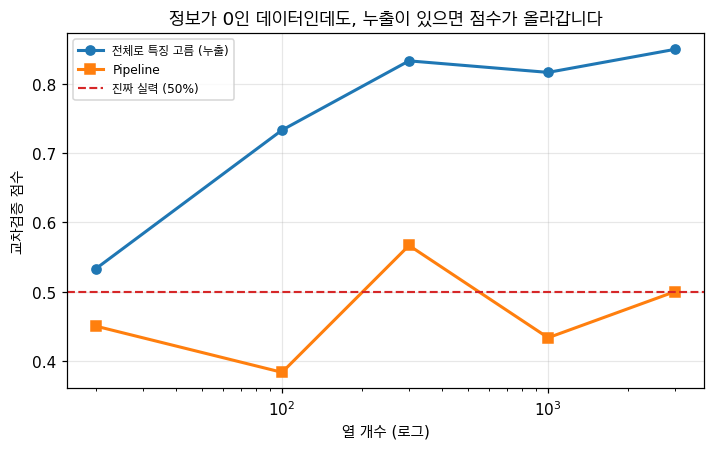


=> 열 20개일 때 부풀림 +8.3%, 열 3000개일 때 +35.0%.
   열이 많아질수록 '우연히 정답과 맞는 열'이 늘어나서, 고를 여지가 커집니다.

   ⚠️ 이게 무서운 이유: **에러도 경고도 안 납니다.** 점수가 좋아 보일 뿐이죠.
      배포하고 나서야 '왜 실제 성능이 이렇지?' 하게 됩니다.


In [8]:
# ✨ 추가 — y를 보는 전처리의 누출은 열이 많아질수록 심해집니다
print(f"{'열 개수':>8}{'❌ 미리 고름':>14}{'✅ Pipeline':>14}{'부풀림':>11}")
print("-" * 50)
누출곡선 = []
for n열 in [20, 100, 300, 1000, 3000]:
    X0, y0 = 무의미데이터(n행=60, n열=n열)
    나쁨 = float(np.mean(cross_val_score(LogisticRegression(max_iter=3000),
                                        SelectKBest(k=10).fit(X0, y0).transform(X0), y0, cv=5)))
    좋음 = float(np.mean(cross_val_score(
        Pipeline([("고르기", SelectKBest(k=10)), ("모델", LogisticRegression(max_iter=3000))]),
        X0, y0, cv=5)))
    누출곡선.append((n열, 나쁨, 좋음))
    print(f"{n열:>8}{나쁨:>14.1%}{좋음:>14.1%}{나쁨-좋음:>+11.1%}")

plt.figure(figsize=(6.6, 4.2))
plt.plot([c[0] for c in 누출곡선], [c[1] for c in 누출곡선], "o-", lw=2,
         label="전체로 특징 고름 (누출)")
plt.plot([c[0] for c in 누출곡선], [c[2] for c in 누출곡선], "s-", lw=2, label="Pipeline")
plt.axhline(0.5, c="tab:red", ls="--", lw=1.4, label="진짜 실력 (50%)")
plt.xscale("log"); plt.xlabel("열 개수 (로그)"); plt.ylabel("교차검증 점수")
plt.title("정보가 0인 데이터인데도, 누출이 있으면 점수가 올라갑니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n=> 열 {누출곡선[0][0]}개일 때 부풀림 {누출곡선[0][1]-누출곡선[0][2]:+.1%}, "
      f"열 {누출곡선[-1][0]}개일 때 {누출곡선[-1][1]-누출곡선[-1][2]:+.1%}.")
print("   열이 많아질수록 '우연히 정답과 맞는 열'이 늘어나서, 고를 여지가 커집니다.")
print("\n   ⚠️ 이게 무서운 이유: **에러도 경고도 안 납니다.** 점수가 좋아 보일 뿐이죠.")
print("      배포하고 나서야 '왜 실제 성능이 이렇지?' 하게 됩니다.")

---

## 3️⃣ 🔨 K-겹 교차검증 (+ 층화)

> 📗 **원문** — "K-Fold Cross-Validation" + "Build It: Step 2"
>
> 🔗 **앞 절과 이어서** — 1·2절에서 나누는 법을 제대로 배웠습니다.
> 그런데 **데이터가 적으면** 문제가 남습니다.
> 1,000행에서 200행을 검증에 떼면 **훈련 데이터가 800행으로 줄고**,
> 게다가 **어느 200행을 떼느냐에 따라 점수가 출렁입니다.**

### 📗 해법 — K번 나눠서 다 써 봅니다

1. 데이터를 **K개 조각(겹, fold)**으로 나눕니다
2. 각 겹에 대해: **나머지 K-1개로 학습**, **그 겹으로 검증**
3. **K개 점수를 평균**합니다

> 📗 K=5 또는 K=10이 표준입니다. **모든 데이터가 정확히 한 번 검증에 쓰입니다.**

### 🧸 비유 — 5명이 돌아가며 심판 보기

친구 5명이 모여 축구 실력을 평가하려 합니다. 심판이 필요한데 사람이 없어요.

**한 명씩 돌아가며 심판을 봅니다.** 5번 하고 평균을 내면,
**모두가 선수로도 뛰고 심판도 봤습니다.** 데이터를 버리지 않은 거죠.

### 📗 층화 K-겹 — 불균형 데이터에서는 필수

> 원문: "preserves the class distribution in each fold."

데이터가 양성 5%라면, 한 겹에 양성이 **0개**일 수도 있습니다.
그러면 그 겹의 점수는 아무 의미가 없습니다.

**층화(stratified)**는 각 겹의 클래스 비율을 전체와 같게 맞춰 줍니다.

In [9]:
# 📗 원문 Step 2 — K-겹과 층화 K-겹
def K겹(n, K=5, 시드=0, 섞기=True):
    # 각 겹에 대해 (훈련 인덱스, 검증 인덱스)를 돌려줍니다
    순서 = np.random.default_rng(시드).permutation(n) if 섞기 else np.arange(n)
    겹들 = np.array_split(순서, K)
    for k in range(K):
        검증 = 겹들[k]
        훈련 = np.concatenate([겹들[j] for j in range(K) if j != k])
        yield 훈련, 검증

def 층화K겹(y, K=5, 시드=0):
    # 클래스별로 K조각씩 만들어, 겹마다 골고루 섞어 넣습니다
    rng = np.random.default_rng(시드)
    클래스별조각 = []
    for c in np.unique(y):
        자리 = rng.permutation(np.where(y == c)[0])
        클래스별조각.append(np.array_split(자리, K))
    for k in range(K):
        검증 = np.concatenate([조각[k] for 조각 in 클래스별조각])
        훈련 = np.concatenate([조각[j] for 조각 in 클래스별조각
                              for j in range(K) if j != k])
        yield 훈련, 검증

def 교차검증점수(만들기, X, y, 겹생성):
    점수 = []
    for 훈련칸, 검증칸 in 겹생성:
        m = 만들기().fit(X[훈련칸], y[훈련칸])
        점수.append(float(m.score(X[검증칸], y[검증칸])))
    return np.array(점수)

print("교차검증 준비 완료")

교차검증 준비 완료


In [10]:
# ✨ 추가 — 한 번 나누기 vs K-겹: 점수가 얼마나 출렁이나
X, y = 불균형데이터(0, n=300, 양성비율=0.5)

한번나누기점수 = []
for 시드 in range(20):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.2, random_state=시드)
    한번나누기점수.append(LogisticRegression(max_iter=1000).fit(Xa, ya).score(Xb, yb))
한번나누기점수 = np.array(한번나누기점수)

K겹점수 = []
for 시드 in range(20):
    점수 = 교차검증점수(lambda: LogisticRegression(max_iter=1000), X, y, K겹(len(y), K=5, 시드=시드))
    K겹점수.append(점수.mean())
K겹점수 = np.array(K겹점수)

print(f"데이터 {len(y)}행. 시드를 20번 바꿔 가며 '평가 점수'를 재 봅니다.\n")
print(f"{'평가 방법':<22}{'평균':>9}{'최저':>9}{'최고':>9}{'표준편차':>11}")
print("-" * 62)
for 이름, 점 in [("한 번 나누기 (20%)", 한번나누기점수), ("5-겹 교차검증", K겹점수)]:
    print(f"{이름:<21}{점.mean():>9.1%}{점.min():>9.1%}{점.max():>9.1%}{점.std():>11.4f}")

print(f"\n=> 평균은 비슷합니다. 그런데 **흔들림이 다릅니다.**")
print(f"   한 번 나누기: 최저 {한번나누기점수.min():.1%} ~ 최고 {한번나누기점수.max():.1%} "
      f"(폭 {한번나누기점수.max()-한번나누기점수.min():.1%}p)")
print(f"   5-겹 교차검증: 최저 {K겹점수.min():.1%} ~ 최고 {K겹점수.max():.1%} "
      f"(폭 {K겹점수.max()-K겹점수.min():.1%}p)")
print(f"   표준편차가 {한번나누기점수.std()/max(K겹점수.std(),1e-12):.1f}배 차이 납니다.")
print("\n   ⚠️ 한 번만 나눠서 '85%!' 라고 보고하면, 운이 좋았을 뿐일 수 있습니다.")
print("      K-겹은 K개 점수의 평균이라 훨씬 안정적입니다.")

데이터 300행. 시드를 20번 바꿔 가며 '평가 점수'를 재 봅니다.

평가 방법                        평균       최저       최고       표준편차
--------------------------------------------------------------
한 번 나누기 (20%)            88.7%    76.7%    98.3%     0.0461
5-겹 교차검증                 87.2%    86.3%    88.3%     0.0050

=> 평균은 비슷합니다. 그런데 **흔들림이 다릅니다.**
   한 번 나누기: 최저 76.7% ~ 최고 98.3% (폭 21.7%p)
   5-겹 교차검증: 최저 86.3% ~ 최고 88.3% (폭 2.0%p)
   표준편차가 9.1배 차이 납니다.

   ⚠️ 한 번만 나눠서 '85%!' 라고 보고하면, 운이 좋았을 뿐일 수 있습니다.
      K-겹은 K개 점수의 평균이라 훨씬 안정적입니다.


In [11]:
# ✨ 추가 — 불균형 데이터에서 층화가 왜 필수인지
X, y = 불균형데이터(0, n=300, 양성비율=0.06)
print(f"데이터 {len(y)}행 중 양성 {int(y.sum())}개 ({y.mean():.1%})\n")

print("일반 K-겹: 각 겹의 양성 개수")
일반겹양성 = []
for k, (훈련칸, 검증칸) in enumerate(K겹(len(y), K=5, 시드=3)):
    일반겹양성.append(int(y[검증칸].sum()))
    print(f"  겹 {k}: 검증 {len(검증칸)}개 중 양성 {int(y[검증칸].sum())}개 "
          f"({y[검증칸].mean():.1%})")

print("\n층화 K-겹: 각 겹의 양성 개수")
층화겹양성 = []
for k, (훈련칸, 검증칸) in enumerate(층화K겹(y, K=5, 시드=3)):
    층화겹양성.append(int(y[검증칸].sum()))
    print(f"  겹 {k}: 검증 {len(검증칸)}개 중 양성 {int(y[검증칸].sum())}개 "
          f"({y[검증칸].mean():.1%})")

print(f"\n일반 K-겹의 양성 개수 폭: {min(일반겹양성)} ~ {max(일반겹양성)}")
print(f"층화 K-겹의 양성 개수 폭: {min(층화겹양성)} ~ {max(층화겹양성)}")
print("\n=> 층화 쪽이 겹마다 고르게 들어갑니다.")
if min(일반겹양성) <= 1:
    print(f"   일반 K-겹에는 양성이 {min(일반겹양성)}개뿐인 겹이 있습니다.")
    print("   그 겹의 재현율은 0% 아니면 100% 밖에 나올 수 없습니다. 평가가 무의미해지죠.")
print("   📗 원문: 'a random split might put all minority samples in one fold'")

데이터 300행 중 양성 16개 (5.3%)

일반 K-겹: 각 겹의 양성 개수
  겹 0: 검증 60개 중 양성 3개 (5.0%)
  겹 1: 검증 60개 중 양성 5개 (8.3%)
  겹 2: 검증 60개 중 양성 3개 (5.0%)
  겹 3: 검증 60개 중 양성 3개 (5.0%)
  겹 4: 검증 60개 중 양성 2개 (3.3%)

층화 K-겹: 각 겹의 양성 개수
  겹 0: 검증 61개 중 양성 4개 (6.6%)
  겹 1: 검증 60개 중 양성 3개 (5.0%)
  겹 2: 검증 60개 중 양성 3개 (5.0%)
  겹 3: 검증 60개 중 양성 3개 (5.0%)
  겹 4: 검증 59개 중 양성 3개 (5.1%)

일반 K-겹의 양성 개수 폭: 2 ~ 5
층화 K-겹의 양성 개수 폭: 3 ~ 4

=> 층화 쪽이 겹마다 고르게 들어갑니다.
   📗 원문: 'a random split might put all minority samples in one fold'


In [12]:
# ✨ 추가 — 그래서 점수가 얼마나 불안정해지나 (일반 vs 층화)
from sklearn.metrics import f1_score

def F1로교차검증(y, 겹생성, X):
    점수 = []
    for 훈련칸, 검증칸 in 겹생성:
        m = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X[훈련칸], y[훈련칸])
        점수.append(f1_score(y[검증칸], m.predict(X[검증칸]), zero_division=0))
    return np.array(점수)

일반들, 층화들 = [], []
for 시드 in range(30):
    일반들.append(F1로교차검증(y, K겹(len(y), K=5, 시드=시드), X).mean())
    층화들.append(F1로교차검증(y, 층화K겹(y, K=5, 시드=시드), X).mean())
일반들, 층화들 = np.array(일반들), np.array(층화들)

print(f"양성 {y.mean():.1%}인 데이터에서 F1 점수를 30번 재 봤습니다.\n")
print(f"{'방법':<16}{'평균 F1':>10}{'최저':>9}{'최고':>9}{'표준편차':>11}")
print("-" * 56)
for 이름, 점 in [("일반 K-겹", 일반들), ("층화 K-겹", 층화들)]:
    print(f"{이름:<15}{점.mean():>10.4f}{점.min():>9.4f}{점.max():>9.4f}{점.std():>11.4f}")

더안정 = "층화" if 층화들.std() < 일반들.std() else "일반"
print(f"\n=> {더안정} K-겹 쪽이 더 안정적입니다 (표준편차가 작음).")
print("   💡 실무 규칙: **분류 문제면 항상 층화를 쓰세요.** 손해 볼 일이 없습니다.")
print("      sklearn의 `cross_val_score`는 분류기를 넘기면 자동으로 층화를 씁니다.")

양성 5.3%인 데이터에서 F1 점수를 30번 재 봤습니다.

방법                   평균 F1       최저       최고       표준편차
--------------------------------------------------------
일반 K-겹             0.5625   0.4988   0.6384     0.0317
층화 K-겹             0.5766   0.5161   0.6344     0.0242

=> 층화 K-겹 쪽이 더 안정적입니다 (표준편차가 작음).
   💡 실무 규칙: **분류 문제면 항상 층화를 쓰세요.** 손해 볼 일이 없습니다.
      sklearn의 `cross_val_score`는 분류기를 넘기면 자동으로 층화를 씁니다.


---

## 4️⃣ 🔨 혼동 행렬과 분류 지표

> 📗 **원문** — "Classification Metrics" + "Build It: Step 3"
>
> 🔗 **앞 절과 이어서** — 여기까지 **어디서 재는지**를 정했습니다.
> 이제 **뭘로 재는지**입니다. 0절의 함정 ①(정확도)을 푸는 도구가 여기 있습니다.
> 3단원 7절에서 맛봤는데, 이번엔 전부 직접 만듭니다.

### 📗 모든 것의 출발점 — 혼동 행렬

| | 양성으로 예측 | 음성으로 예측 |
| --- | --- | --- |
| **실제 양성** | TP (맞게 잡음) | FN (놓침) |
| **실제 음성** | FP (헛짚음) | TN (맞게 넘김) |

이 네 숫자에서 **모든 지표가 나옵니다.**

| 지표 | 식 | 한 줄 뜻 | 언제 |
| --- | --- | --- | --- |
| **정확도** | $\dfrac{TP+TN}{\text{전체}}$ | 전체 중 맞힌 비율 | ⚠️ 불균형이면 속습니다 |
| **정밀도** | $\dfrac{TP}{TP+FP}$ | **양성이라 한 것 중** 진짜 비율 | **헛짚으면 곤란할 때** (스팸 필터) |
| **재현율** | $\dfrac{TP}{TP+FN}$ | **진짜 양성 중** 잡아낸 비율 | **놓치면 곤란할 때** (암 검진) |
| **F1** | $\dfrac{2 \cdot P \cdot R}{P+R}$ | 정밀도와 재현율의 **조화평균** | 둘 다 중요할 때 |

### 🧸 왜 F1은 '조화평균'인가요?

산술평균이면 정밀도 100%, 재현율 0%인 모델의 점수가 **50점**입니다.
쓸모없는 모델에 절반 점수를 주는 거죠.

조화평균은 $\frac{2 \times 1.0 \times 0}{1.0 + 0} = 0$ 입니다.
**한쪽이 0이면 전체가 0.** 양쪽 다 괜찮아야 점수가 나옵니다.

In [13]:
# 📗 원문 Step 3 — 혼동 행렬과 분류 지표
def 혼동행렬(y진짜, y예측, 클래스=None):
    클래스 = np.unique(np.concatenate([y진짜, y예측])) if 클래스 is None else np.asarray(클래스)
    자리 = {c: i for i, c in enumerate(클래스)}
    M = np.zeros((len(클래스), len(클래스)), dtype=int)
    for t, p in zip(y진짜, y예측):
        M[자리[t], 자리[p]] += 1        # 행 = 실제, 열 = 예측
    return M, 클래스

def 이진지표(y진짜, y예측):
    TP = int(((y예측 == 1) & (y진짜 == 1)).sum())
    FP = int(((y예측 == 1) & (y진짜 == 0)).sum())
    FN = int(((y예측 == 0) & (y진짜 == 1)).sum())
    TN = int(((y예측 == 0) & (y진짜 == 0)).sum())
    정확도 = (TP + TN) / max(TP + TN + FP + FN, 1)
    정밀도 = TP / max(TP + FP, 1) if TP + FP > 0 else 0.0
    재현율 = TP / max(TP + FN, 1) if TP + FN > 0 else 0.0
    F1 = 2 * 정밀도 * 재현율 / (정밀도 + 재현율) if 정밀도 + 재현율 > 0 else 0.0
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "정확도": 정확도, "정밀도": 정밀도, "재현율": 재현율, "F1": F1}

# sklearn과 값이 같은지 확인
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

X, y = 불균형데이터(0, n=2000, 양성비율=0.10)
훈련칸, _, 테스트칸 = 셋으로나누기(X, y, 검증비율=0.0, 테스트비율=0.3, 시드=0)
m = LogisticRegression(max_iter=1000).fit(X[훈련칸], y[훈련칸])
예측 = m.predict(X[테스트칸])
진짜 = y[테스트칸]

내지표 = 이진지표(진짜, 예측)
print(f"{'지표':<10}{'직접 만든 것':>14}{'sklearn':>12}")
print("-" * 38)
print(f"{'정확도':<9}{내지표['정확도']:>15.6f}{accuracy_score(진짜, 예측):>12.6f}")
print(f"{'정밀도':<9}{내지표['정밀도']:>15.6f}{precision_score(진짜, 예측):>12.6f}")
print(f"{'재현율':<9}{내지표['재현율']:>15.6f}{recall_score(진짜, 예측):>12.6f}")
print(f"\n혼동 행렬 (직접):\n{혼동행렬(진짜, 예측)[0]}")
print(f"혼동 행렬 (sklearn):\n{confusion_matrix(진짜, 예측)}")
print("\n=> 같으면 제대로 만든 겁니다.")

지표               직접 만든 것     sklearn
--------------------------------------
정확도             0.933333    0.933333
정밀도             0.708333    0.708333
재현율             0.566667    0.566667

혼동 행렬 (직접):
[[526  14]
 [ 26  34]]
혼동 행렬 (sklearn):
[[526  14]
 [ 26  34]]

=> 같으면 제대로 만든 겁니다.


In [14]:
# ✨ 추가 — 0절의 '정확도 함정'을 이제 제대로 진단합니다
바보 = 무조건다수클래스().fit(X[훈련칸], y[훈련칸])
균형 = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X[훈련칸], y[훈련칸])

print(f"테스트 세트: {len(테스트칸)}개 중 양성 {int(진짜.sum())}개 ({진짜.mean():.1%})\n")
print(f"{'모델':<24}{'정확도':>9}{'정밀도':>9}{'재현율':>9}{'F1':>9}")
print("-" * 62)
for 이름, mm in [("'아니오'만 답함", 바보), ("로지스틱 (기본)", m), ("로지스틱 (가중치 균형)", 균형)]:
    g = 이진지표(진짜, mm.predict(X[테스트칸]))
    print(f"{이름:<23}{g['정확도']:>9.1%}{g['정밀도']:>9.1%}{g['재현율']:>9.1%}{g['F1']:>9.3f}")

바보지표 = 이진지표(진짜, 바보.predict(X[테스트칸]))
print(f"\n=> 첫 줄을 보세요. 정확도는 {바보지표['정확도']:.1%}인데 F1은 {바보지표['F1']:.3f}입니다.")
print("   정확도만 보면 '꽤 괜찮은 모델'로 보이고, F1을 보면 '아무것도 못 하는 모델'로 보입니다.")
print("   **F1이 맞습니다.** 양성을 하나도 못 찾았으니까요.")
print("\n   세 번째 줄(가중치 균형)은 정확도가 오히려 낮은데 F1은 가장 높습니다.")
print("   ⚠️ 즉 **지표를 뭘로 고르냐에 따라 '최고의 모델'이 달라집니다.**")
print("      📗 원문: 'The wrong metric makes a bad model look good.'")

테스트 세트: 600개 중 양성 60개 (10.0%)

모델                            정확도      정밀도      재현율       F1
--------------------------------------------------------------
'아니오'만 답함                  90.0%     0.0%     0.0%    0.000
로지스틱 (기본)                  93.3%    70.8%    56.7%    0.630
로지스틱 (가중치 균형)              86.2%    41.1%    88.3%    0.561

=> 첫 줄을 보세요. 정확도는 90.0%인데 F1은 0.000입니다.
   정확도만 보면 '꽤 괜찮은 모델'로 보이고, F1을 보면 '아무것도 못 하는 모델'로 보입니다.
   **F1이 맞습니다.** 양성을 하나도 못 찾았으니까요.

   세 번째 줄(가중치 균형)은 정확도가 오히려 낮은데 F1은 가장 높습니다.
   ⚠️ 즉 **지표를 뭘로 고르냐에 따라 '최고의 모델'이 달라집니다.**
      📗 원문: 'The wrong metric makes a bad model look good.'


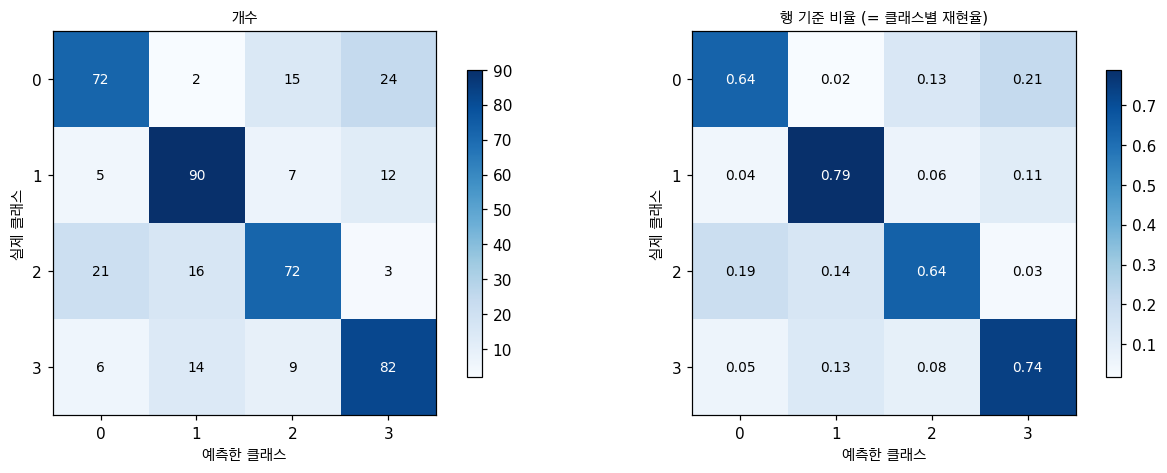

클래스별 재현율: [0.637 0.789 0.643 0.739]
=> 클래스 0이 가장 약합니다 (재현율 63.7%).
   주로 클래스 3으로 잘못 예측합니다 (24번).

💡 혼동 행렬의 진짜 가치는 '어디서 틀리는지'를 보여 주는 것입니다.
   숫자 하나(정확도)로는 절대 알 수 없는 정보죠.


In [15]:
# ✨ 추가 — 혼동 행렬을 그림으로 (다중 분류도 함께)
from sklearn.datasets import make_classification

X다, y다 = make_classification(n_samples=1500, n_features=8, n_informative=5,
                              n_classes=4, n_clusters_per_class=1, random_state=0)
Xa, Xb, ya, yb = train_test_split(X다, y다, test_size=0.3, random_state=0, stratify=y다)
m다 = LogisticRegression(max_iter=3000).fit(Xa, ya)
M, 클래스 = 혼동행렬(yb, m다.predict(Xb))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for a_, (제목, 행렬) in zip(ax, [("개수", M), ("행 기준 비율 (= 클래스별 재현율)",
                                  M / M.sum(axis=1, keepdims=True))]):
    그림 = a_.imshow(행렬, cmap="Blues")
    for i in range(len(클래스)):
        for j in range(len(클래스)):
            v = 행렬[i, j]
            글자 = f"{v:d}" if 행렬.dtype.kind == "i" else f"{v:.2f}"
            a_.text(j, i, 글자, ha="center", va="center", fontsize=9,
                    color="white" if v > 행렬.max() * 0.55 else "black")
    a_.set_xticks(range(len(클래스))); a_.set_yticks(range(len(클래스)))
    a_.set_xlabel("예측한 클래스"); a_.set_ylabel("실제 클래스")
    a_.set_title(제목, fontsize=10)
    plt.colorbar(그림, ax=a_, shrink=0.8)
plt.tight_layout(); plt.show()

대각선 = np.diag(M)
행합 = M.sum(axis=1)
가장약한 = int(np.argmin(대각선 / 행합))
print(f"클래스별 재현율: {np.round(대각선/행합, 3)}")
print(f"=> 클래스 {가장약한}이 가장 약합니다 (재현율 {대각선[가장약한]/행합[가장약한]:.1%}).")
헷갈린곳 = int(np.argmax([M[가장약한, j] if j != 가장약한 else -1 for j in range(len(클래스))]))
print(f"   주로 클래스 {헷갈린곳}으로 잘못 예측합니다 ({M[가장약한, 헷갈린곳]}번).")
print("\n💡 혼동 행렬의 진짜 가치는 '어디서 틀리는지'를 보여 주는 것입니다.")
print("   숫자 하나(정확도)로는 절대 알 수 없는 정보죠.")

---

## 5️⃣ 🔑 AUC-ROC — 임곗값과 무관한 지표

> 📗 **원문** — "Classification Metrics: AUC-ROC"
>
> 🔗 **앞 절과 이어서** — 4절 지표들에는 **숨은 가정**이 하나 있습니다.
> 확률이 **0.5를 넘으면 양성**이라고 잘랐다는 것이죠.
> 3단원 8절에서 봤듯이 **이 0.5는 그냥 기본값**입니다. 옮기면 정밀도·재현율이 다 바뀝니다.
>
> 그러면 **임곗값을 정하기 전에** 모델을 평가할 방법은 없을까요?

### 📗 ROC 곡선

임곗값을 1에서 0까지 쭉 내리면서 두 값을 그립니다.

- **TPR (참 양성률) = 재현율** = $\dfrac{TP}{TP+FN}$ — 세로축
- **FPR (거짓 양성률)** = $\dfrac{FP}{FP+TN}$ — 가로축

**AUC**는 그 곡선 아래 면적입니다.

| AUC | 뜻 |
| --- | --- |
| **0.5** | 찍기와 같음 (대각선) |
| **1.0** | 완벽하게 갈림 |
| **< 0.5** | 예측을 뒤집으면 더 나음 (뭔가 잘못됨) |

### 🧸 AUC의 진짜 의미 — 이게 가장 중요합니다

> **AUC = 무작위로 고른 양성 하나가, 무작위로 고른 음성 하나보다 높은 점수를 받을 확률**

즉 AUC는 **"모델이 순위를 잘 매기는가"**를 재는 지표입니다.
임곗값이 어디든 상관없어요. **순서만 맞으면** AUC가 높습니다.

### 🧸 비유 — 지원자 100명 줄 세우기

채용에서 지원자 100명을 실력 순으로 줄 세워야 합니다.

- **정확도**는 "합격선을 70점에 그었을 때 몇 명을 제대로 갈랐나"입니다. **합격선에 따라 달라집니다.**
- **AUC**는 "줄 세운 순서가 실제 실력 순서와 얼마나 맞나"입니다. **합격선과 무관합니다.**

> ⚠️ **AUC의 약점**: 불균형이 심하면 AUC가 낙관적으로 나옵니다.
> 음성이 압도적으로 많으면 FPR 분모가 커서, FP가 꽤 많아도 FPR이 작게 보이거든요.
> 그럴 때는 **PR 곡선(정밀도-재현율 곡선)**을 함께 봅니다. 아래에서 확인합니다.

In [16]:
# ✨ 추가 — ROC 곡선과 AUC를 직접 구현합니다
def ROC곡선(y진짜, 점수):
    # 점수가 높은 순으로 정렬하며 임곗값을 내립니다
    순서 = np.argsort(점수)[::-1]
    y정렬 = np.asarray(y진짜)[순서]
    양성수 = int(y정렬.sum())
    음성수 = len(y정렬) - 양성수
    TPR = np.concatenate([[0.0], np.cumsum(y정렬) / 양성수])
    FPR = np.concatenate([[0.0], np.cumsum(1 - y정렬) / 음성수])
    return FPR, TPR

def AUC(y진짜, 점수):
    FPR, TPR = ROC곡선(y진짜, 점수)
    return float(np.trapz(TPR, FPR))         # 사다리꼴 적분

def AUC순위로(y진짜, 점수):
    # ⭐ 정의 그대로: 양성 하나가 음성 하나보다 점수가 높을 확률
    y진짜 = np.asarray(y진짜)
    양성점수 = 점수[y진짜 == 1]
    음성점수 = 점수[y진짜 == 0]
    이김 = (양성점수[:, None] > 음성점수[None, :]).sum()
    동점 = (양성점수[:, None] == 음성점수[None, :]).sum()
    return float((이김 + 0.5 * 동점) / (len(양성점수) * len(음성점수)))

from sklearn.metrics import roc_auc_score, roc_curve

확률 = m.predict_proba(X[테스트칸])[:, 1]
print(f"{'계산 방법':<28}{'AUC':>10}")
print("-" * 40)
print(f"{'직접 구현 (곡선 아래 면적)':<26}{AUC(진짜, 확률):>11.6f}")
print(f"{'직접 구현 (순위 정의 그대로)':<25}{AUC순위로(진짜, 확률):>11.6f}")
print(f"{'sklearn':<27}{roc_auc_score(진짜, 확률):>11.6f}")
print("\n=> 세 값이 같습니다. '곡선 아래 면적'과 '순위 확률'이 정말 같은 값이라는 뜻이죠.")
print("   이게 AUC를 이해하는 가장 좋은 방법입니다. AUC는 순위 품질입니다.")

계산 방법                              AUC
----------------------------------------
직접 구현 (곡선 아래 면적)             0.947130
직접 구현 (순위 정의 그대로)           0.947130
sklearn                       0.947130

=> 세 값이 같습니다. '곡선 아래 면적'과 '순위 확률'이 정말 같은 값이라는 뜻이죠.
   이게 AUC를 이해하는 가장 좋은 방법입니다. AUC는 순위 품질입니다.


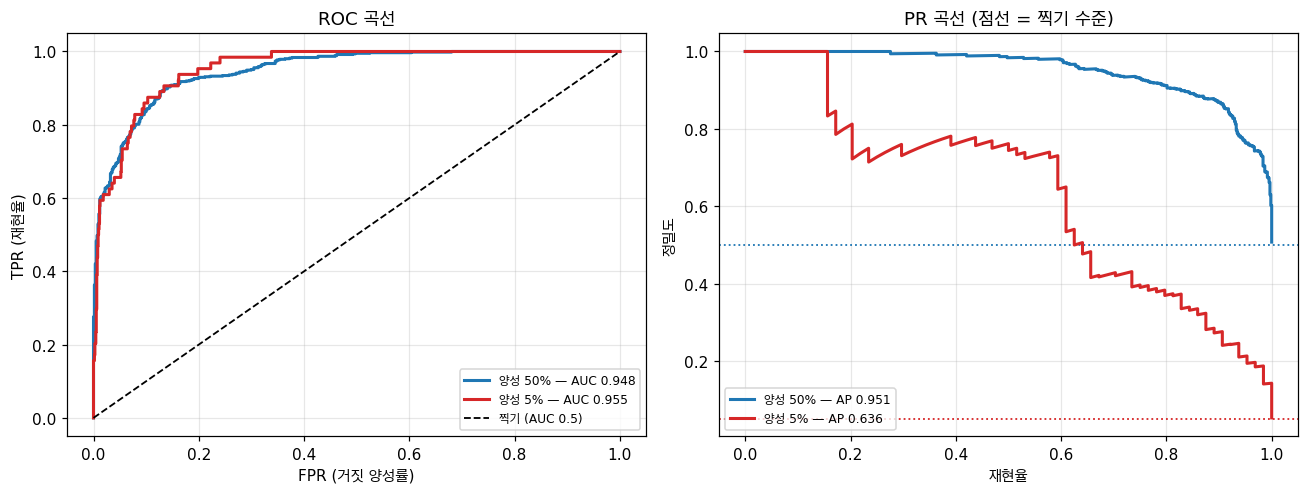

=> ROC 곡선(왼쪽): 두 경우의 AUC가 비슷합니다. 불균형이 심해도 AUC는 잘 안 떨어집니다.
   PR 곡선(오른쪽): 양성 5%일 때 곡선이 확 내려앉습니다. 정밀도가 훨씬 나쁘다는 뜻이죠.

⚠️ 왜 이런 차이가 나나요?
   FPR의 분모(FP + TN)에는 **음성 전체**가 들어갑니다.
   음성이 1000개라면 헛짚음(FP)이 50개여도 FPR은 5%밖에 안 됩니다. 작아 보이죠.
   반면 정밀도의 분모(TP + FP)에는 음성 전체가 안 들어갑니다.
   양성이 50개뿐인데 FP가 50개면 정밀도가 50%로 곧바로 드러납니다.
   => 같은 실수인데 FPR로 보면 5%, 정밀도로 보면 50% 손실입니다.

💡 실무 규칙: **불균형이 심하면 AUC-ROC 대신 PR 곡선(또는 AP)을 보세요.**


In [17]:
# ✨ 추가 — ROC 곡선과 PR 곡선을 나란히 (불균형일 때의 차이)
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

for 양성비율, 색 in [(0.5, "tab:blue"), (0.05, "tab:red")]:
    Xi, yi = 불균형데이터(0, n=4000, 양성비율=양성비율)
    a, b, ya_, yb_ = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)
    mi = LogisticRegression(max_iter=1000).fit(a, ya_)
    점수 = mi.predict_proba(b)[:, 1]

    FPR, TPR = ROC곡선(yb_, 점수)
    ax[0].plot(FPR, TPR, lw=2, c=색, label=f"양성 {양성비율:.0%} — AUC {AUC(yb_, 점수):.3f}")

    정밀도, 재현율, _ = precision_recall_curve(yb_, 점수)
    ax[1].plot(재현율, 정밀도, lw=2, c=색,
               label=f"양성 {양성비율:.0%} — AP {average_precision_score(yb_, 점수):.3f}")
    ax[1].axhline(양성비율, c=색, ls=":", lw=1.2)

ax[0].plot([0, 1], [0, 1], "k--", lw=1.2, label="찍기 (AUC 0.5)")
ax[0].set_xlabel("FPR (거짓 양성률)"); ax[0].set_ylabel("TPR (재현율)")
ax[0].set_title("ROC 곡선"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("재현율"); ax[1].set_ylabel("정밀도")
ax[1].set_title("PR 곡선 (점선 = 찍기 수준)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("=> ROC 곡선(왼쪽): 두 경우의 AUC가 비슷합니다. 불균형이 심해도 AUC는 잘 안 떨어집니다.")
print("   PR 곡선(오른쪽): 양성 5%일 때 곡선이 확 내려앉습니다. 정밀도가 훨씬 나쁘다는 뜻이죠.")
print("\n⚠️ 왜 이런 차이가 나나요?")
print("   FPR의 분모(FP + TN)에는 **음성 전체**가 들어갑니다.")
print("   음성이 1000개라면 헛짚음(FP)이 50개여도 FPR은 5%밖에 안 됩니다. 작아 보이죠.")
print("   반면 정밀도의 분모(TP + FP)에는 음성 전체가 안 들어갑니다.")
print("   양성이 50개뿐인데 FP가 50개면 정밀도가 50%로 곧바로 드러납니다.")
print("   => 같은 실수인데 FPR로 보면 5%, 정밀도로 보면 50% 손실입니다.")
print("\n💡 실무 규칙: **불균형이 심하면 AUC-ROC 대신 PR 곡선(또는 AP)을 보세요.**")

In [18]:
# ✨ 추가 — AUC가 같은데 임곗값별 성능이 다를 수 있습니다
Xi, yi = 불균형데이터(0, n=3000, 양성비율=0.2)
a, b, ya_, yb_ = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)
mi = LogisticRegression(max_iter=1000).fit(a, ya_)
점수 = mi.predict_proba(b)[:, 1]

print(f"이 모델의 AUC = {AUC(yb_, 점수):.4f}  (임곗값과 무관한 값)\n")
print(f"{'임곗값':>8}{'정확도':>9}{'정밀도':>9}{'재현율':>9}{'F1':>9}   쓸 곳")
print("-" * 62)
for t in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    g = 이진지표(yb_, (점수 >= t).astype(int))
    쓸곳 = "놓치면 안 될 때" if t < 0.3 else ("기본값" if t == 0.5 else "헛짚으면 안 될 때")
    print(f"{t:>8.1f}{g['정확도']:>9.1%}{g['정밀도']:>9.1%}{g['재현율']:>9.1%}{g['F1']:>9.3f}   {쓸곳}")

F1들 = [(t, 이진지표(yb_, (점수 >= t).astype(int))["F1"]) for t in np.arange(0.05, 0.96, 0.01)]
최고t, 최고F1 = max(F1들, key=lambda x: x[1])
기본F1 = 이진지표(yb_, (점수 >= 0.5).astype(int))["F1"]
print(f"\n=> AUC는 이 표 전체를 한 숫자로 요약합니다. 임곗값을 안 정해도 되니 편하죠.")
print(f"   그런데 **실제 서비스에서는 임곗값을 반드시 하나 골라야** 합니다.")
print(f"   F1이 최대가 되는 임곗값 = {최고t:.2f} (F1 {최고F1:.3f})")
print(f"   기본값 0.5를 쓰면      F1 {기본F1:.3f}  ({최고F1-기본F1:+.3f})")
print("\n💡 정리: **AUC로 모델을 고르고, 임곗값은 따로 검증 세트에서 정하세요.**")
print("   ⚠️ 임곗값도 하이퍼파라미터입니다. 테스트 세트에서 고르면 안 됩니다!")

이 모델의 AUC = 0.9382  (임곗값과 무관한 값)

     임곗값      정확도      정밀도      재현율       F1   쓸 곳
--------------------------------------------------------------
     0.1    78.7%    49.4%    93.1%    0.646   놓치면 안 될 때
     0.2    85.4%    60.5%    87.2%    0.715   놓치면 안 될 때
     0.3    88.9%    69.3%    84.0%    0.760   헛짚으면 안 될 때
     0.5    90.7%    82.1%    70.7%    0.760   기본값
     0.7    89.8%    91.4%    56.4%    0.697   헛짚으면 안 될 때
     0.9    85.6%    95.3%    32.4%    0.484   헛짚으면 안 될 때

=> AUC는 이 표 전체를 한 숫자로 요약합니다. 임곗값을 안 정해도 되니 편하죠.
   그런데 **실제 서비스에서는 임곗값을 반드시 하나 골라야** 합니다.
   F1이 최대가 되는 임곗값 = 0.35 (F1 0.777)
   기본값 0.5를 쓰면      F1 0.760  (+0.017)

💡 정리: **AUC로 모델을 고르고, 임곗값은 따로 검증 세트에서 정하세요.**
   ⚠️ 임곗값도 하이퍼파라미터입니다. 테스트 세트에서 고르면 안 됩니다!


---

## 6️⃣ 🔨 회귀 지표 — MSE · RMSE · MAE · R²

> 📗 **원문** — "Regression Metrics" + "Build It: Step 4"
>
> 🔗 **앞 절과 이어서** — 4·5절은 전부 **분류**였습니다.
> 숫자를 예측하는 회귀는 **지표가 통째로 다릅니다.** 혼동 행렬이 없으니까요.

| 지표 | 식 | 성격 |
| --- | --- | --- |
| **MSE** | $\text{mean}\bigl((y-\hat{y})^2\bigr)$ | 큰 오차에 **제곱으로** 벌점. 이상치에 민감 |
| **RMSE** | $\sqrt{\text{MSE}}$ | **단위가 목표와 같아서** 해석이 쉽습니다 |
| **MAE** | $\text{mean}\bigl(\lvert y-\hat{y}\rvert\bigr)$ | 오차를 **선형으로**. 이상치에 강함 |
| **R²** | $1 - \dfrac{SS_{res}}{SS_{tot}}$ | 분산을 몇 % 설명했나. **단위 무관** |

### 🧸 RMSE와 MAE의 차이 — 숫자로 느껴 보기

오차가 `[1, 1, 1, 1, 10]` 이라고 해 봅시다.

- **MAE** = (1+1+1+1+10)/5 = **2.8**
- **RMSE** = √((1+1+1+1+100)/5) = √20.8 = **4.56**

**RMSE가 훨씬 큽니다.** 10짜리 오차 하나가 제곱되어 104개 중 100을 차지하니까요.

> ⚠️ 그래서 **이상치가 있으면 둘이 정반대 판단을 합니다.**
> "가끔 크게 틀리는 모델"과 "항상 조금씩 틀리는 모델" 중 누가 나은가?
> **MSE는 후자를, MAE는 전자를 고릅니다.** 아래에서 확인합니다.

### 📗 R² 읽는 법

| R² | 뜻 |
| --- | --- |
| **1.0** | 완벽 |
| **0.0** | **항상 평균만 답하는 것과 같음** |
| **음수** | 평균보다도 못함 (뭔가 잘못됨) |

> 🧸 R²는 "평균만 답하는 모델"을 0점 기준으로 삼은 점수입니다.
> 1단원 8절에서 배운 **기준선 비교**가 지표에 아예 내장된 셈이죠.

In [19]:
# 📗 원문 Step 4 — 회귀 지표
def MSE(y진짜, y예측):
    return float(np.mean((np.asarray(y진짜) - np.asarray(y예측)) ** 2))

def RMSE(y진짜, y예측):
    return math.sqrt(MSE(y진짜, y예측))

def MAE(y진짜, y예측):
    return float(np.mean(np.abs(np.asarray(y진짜) - np.asarray(y예측))))

def R2(y진짜, y예측):
    y진짜 = np.asarray(y진짜, dtype=float)
    잔차제곱합 = float(((y진짜 - np.asarray(y예측)) ** 2).sum())
    전체제곱합 = float(((y진짜 - y진짜.mean()) ** 2).sum())
    return 1.0 - 잔차제곱합 / max(전체제곱합, 1e-12)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r = np.random.default_rng(0)
X회 = r.uniform(0, 10, (400, 1))
y회 = 3.0 * X회.ravel() + 5.0 + r.normal(0, 2.0, 400)
a, b, ya_, yb_ = train_test_split(X회, y회, test_size=0.3, random_state=0)
mr = LinearRegression().fit(a, ya_)
예측회 = mr.predict(b)

print(f"{'지표':<10}{'직접 만든 것':>14}{'sklearn':>12}")
print("-" * 38)
print(f"{'MSE':<9}{MSE(yb_, 예측회):>15.6f}{mean_squared_error(yb_, 예측회):>12.6f}")
print(f"{'MAE':<9}{MAE(yb_, 예측회):>15.6f}{mean_absolute_error(yb_, 예측회):>12.6f}")
print(f"{'R²':<9}{R2(yb_, 예측회):>15.6f}{r2_score(yb_, 예측회):>12.6f}")
print(f"{'RMSE':<9}{RMSE(yb_, 예측회):>15.6f}{'(직접 계산)':>12}")

print(f"\n목표값의 범위: {y회.min():.1f} ~ {y회.max():.1f}")
print(f"RMSE {RMSE(yb_, 예측회):.2f} = '평균적으로 이만큼 틀린다'로 읽을 수 있습니다.")
print(f"MSE {MSE(yb_, 예측회):.2f} 는 단위가 '목표의 제곱'이라 감이 안 옵니다.")
print("=> 보고할 때는 RMSE를 쓰세요. 최적화할 때는 MSE가 미분이 쉬워서 편합니다.")

지표               직접 만든 것     sklearn
--------------------------------------
MSE             4.857981    4.857981
MAE             1.800597    1.800597
R²              0.940684    0.940684
RMSE            2.204083     (직접 계산)

목표값의 범위: 1.5 ~ 37.9
RMSE 2.20 = '평균적으로 이만큼 틀린다'로 읽을 수 있습니다.
MSE 4.86 는 단위가 '목표의 제곱'이라 감이 안 옵니다.
=> 보고할 때는 RMSE를 쓰세요. 최적화할 때는 MSE가 미분이 쉬워서 편합니다.


모델                                MAE     RMSE      최대 오차
----------------------------------------------------------
A: 항상 조금씩 틀림                   1.641    2.037      6.213
B: 대개 정확, 가끔 크게 틀림             0.858    2.979     18.000

MAE 가 고르는 모델 : B
RMSE 가 고르는 모델: A

=> ⚠️ **두 지표가 정반대 모델을 고릅니다.**
   RMSE는 큰 실수를 제곱해서 미워합니다. 그래서 '가끔 크게 틀리는' B를 싫어하죠.
   MAE는 오차를 그대로 더합니다. B가 평소에 정확하니 총합이 작아 B를 좋아합니다.

   💡 그럼 뭘 써야 하나요? **비용 구조를 보세요.**
      · 배송 시간 예측: 10분 늦는 게 1분씩 10번 늦는 것보다 훨씬 나쁘다 -> RMSE
      · 매출 예측 합계: 오차가 상쇄되니 총량이 중요하다 -> MAE
      📗 원문: 'optimizing RMSE when your data has heavy outliers (use MAE instead)'


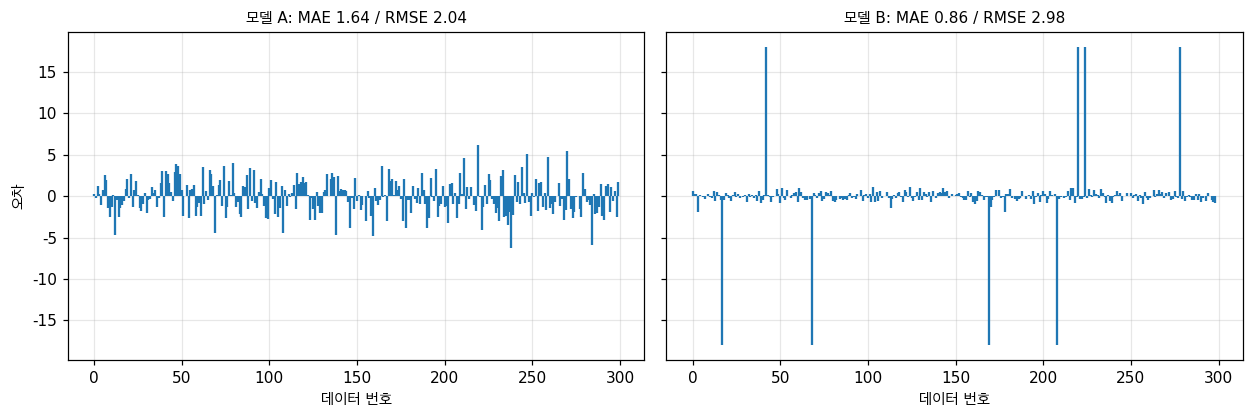

In [20]:
# ✨ 추가 — MSE와 MAE가 '다른 모델을 고르는' 경우
r = np.random.default_rng(0)
n = 300
# 모델 A: 항상 조금씩 틀립니다
오차A = r.normal(0, 2.0, n)
# 모델 B: 대개 아주 정확한데, 가끔 크게 틀립니다
오차B = r.normal(0, 0.5, n)
큰실수자리 = r.choice(n, 8, replace=False)
오차B[큰실수자리] = 18.0 * (r.integers(0, 2, 8) * 2 - 1)      # 크기를 18로 고정 (운에 안 맡깁니다)

진짜값 = r.uniform(0, 100, n)
print(f"{'모델':<28}{'MAE':>9}{'RMSE':>9}{'최대 오차':>11}")
print("-" * 58)
for 이름, 오차 in [("A: 항상 조금씩 틀림", 오차A), ("B: 대개 정확, 가끔 크게 틀림", 오차B)]:
    print(f"{이름:<26}{MAE(진짜값, 진짜값+오차):>10.3f}"
          f"{RMSE(진짜값, 진짜값+오차):>9.3f}{np.abs(오차).max():>11.3f}")

MAE승자 = "A" if MAE(진짜값, 진짜값+오차A) < MAE(진짜값, 진짜값+오차B) else "B"
RMSE승자 = "A" if RMSE(진짜값, 진짜값+오차A) < RMSE(진짜값, 진짜값+오차B) else "B"
print(f"\nMAE 가 고르는 모델 : {MAE승자}")
print(f"RMSE 가 고르는 모델: {RMSE승자}")
if MAE승자 != RMSE승자:
    print("\n=> ⚠️ **두 지표가 정반대 모델을 고릅니다.**")
    print("   RMSE는 큰 실수를 제곱해서 미워합니다. 그래서 '가끔 크게 틀리는' B를 싫어하죠.")
    print("   MAE는 오차를 그대로 더합니다. B가 평소에 정확하니 총합이 작아 B를 좋아합니다.")
    print("\n   💡 그럼 뭘 써야 하나요? **비용 구조를 보세요.**")
    print("      · 배송 시간 예측: 10분 늦는 게 1분씩 10번 늦는 것보다 훨씬 나쁘다 -> RMSE")
    print("      · 매출 예측 합계: 오차가 상쇄되니 총량이 중요하다 -> MAE")
    print("      📗 원문: 'optimizing RMSE when your data has heavy outliers (use MAE instead)'")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
for a_, (이름, 오차) in zip(ax, [("모델 A", 오차A), ("모델 B", 오차B)]):
    a_.stem(np.arange(n), 오차, markerfmt=" ", basefmt=" ", linefmt="C0-")
    a_.set_title(f"{이름}: MAE {MAE(진짜값,진짜값+오차):.2f} / RMSE {RMSE(진짜값,진짜값+오차):.2f}",
                 fontsize=10)
    a_.set_xlabel("데이터 번호"); a_.grid(alpha=0.3)
ax[0].set_ylabel("오차")
plt.tight_layout(); plt.show()

In [21]:
# ✨ 추가 — R²가 음수가 되는 경우
r = np.random.default_rng(0)
y테스트 = r.normal(50, 10, 100)

경우들 = [
    ("완벽한 예측", y테스트),
    ("평균만 답하기", np.full(100, y테스트.mean())),
    ("평균만 답하기 (훈련 평균이 어긋남)", np.full(100, y테스트.mean() + 12)),
    ("완전 무작위 예측", r.normal(50, 10, 100)),
    ("예측을 뒤집음", 100 - y테스트),
]
print(f"{'예측 방식':<34}{'R²':>10}{'RMSE':>10}")
print("-" * 56)
for 이름, 예측 in 경우들:
    print(f"{이름:<33}{R2(y테스트, 예측):>10.3f}{RMSE(y테스트, 예측):>10.2f}")

print("\n=> '평균만 답하기'가 정확히 0.000입니다. 이게 R²의 0점 기준입니다.")
print("   그 아래는 전부 음수입니다. **평균만 답하는 것보다 못하다**는 뜻이죠.")
print("\n⚠️ 실무에서 R²가 음수로 나오면 대개 이 중 하나입니다.")
print("   ① 훈련 데이터와 테스트 데이터의 분포가 다르다 (세 번째 줄이 그 경우)")
print("   ② 과적합이 심하다")
print("   ③ 전처리를 테스트에 잘못 적용했다 (2절의 누출과 반대 방향 실수)")

예측 방식                                     R²      RMSE
--------------------------------------------------------
완벽한 예측                                1.000      0.00
평균만 답하기                               0.000      9.62
평균만 답하기 (훈련 평균이 어긋남)                 -1.556     15.38
완전 무작위 예측                            -0.895     13.25
예측을 뒤집음                              -3.028     19.31

=> '평균만 답하기'가 정확히 0.000입니다. 이게 R²의 0점 기준입니다.
   그 아래는 전부 음수입니다. **평균만 답하는 것보다 못하다**는 뜻이죠.

⚠️ 실무에서 R²가 음수로 나오면 대개 이 중 하나입니다.
   ① 훈련 데이터와 테스트 데이터의 분포가 다르다 (세 번째 줄이 그 경우)
   ② 과적합이 심하다
   ③ 전처리를 테스트에 잘못 적용했다 (2절의 누출과 반대 방향 실수)


---

## 7️⃣ 학습 곡선 — 데이터를 더 모을까, 모델을 키울까

> 📗 **원문** — "Learning Curves" + "Build It: Step 5"
>
> 🔗 **여기서 목적이 바뀝니다** — 1~6절은 **"점수를 정확히 재는 법"**이었습니다.
> 이제 **"재서 무엇을 할지"**입니다. 그리고 이게 실무에서 가장 값진 부분입니다.

### 실무에서 가장 자주 하는 질문

성능이 목표에 못 미칩니다. 그럼 **뭘 해야 하나요?**

- 데이터를 더 모을까? (돈과 시간이 많이 듭니다)
- 모델을 더 크게 할까?
- 특징을 더 만들까?

**학습 곡선이 이 질문에 답해 줍니다.**

### 📗 그리는 방법

**훈련 데이터 크기를 늘려 가며** 훈련 점수와 검증 점수를 둘 다 그립니다.

### 📗 읽는 방법

| 모양 | 진단 | 처방 |
| --- | --- | --- |
| 두 곡선이 **낮은 값에서 붙어 있음** | **고편향 (과소적합)** | **데이터를 더 모아도 소용없습니다.** 모델을 키우거나 특징을 늘리세요 |
| 훈련은 높고 검증은 낮음 (**간격이 큼**) | **고분산 (과적합)** | **데이터를 더 모으면 도움이 됩니다.** 또는 규제를 세게 |

### 🧸 왜 그런가요?

- **고편향** = 모델이 애초에 무늬를 표현할 능력이 없습니다.
  직선으로 곡선을 맞추려는 셈이죠. **데이터를 100만 개 줘도 직선은 직선입니다.**
- **고분산** = 모델은 충분히 똑똑한데 데이터가 적어서 잡음을 외웁니다.
  **데이터가 늘면 잡음이 평균되어 사라집니다.**

> 💡 이 진단 하나로 **몇 주의 삽질을 줄일 수 있습니다.** 고편향인데 데이터를 더 모으면
> 돈과 시간을 버리는 거니까요.

In [22]:
# 📗 원문 Step 5 — 학습 곡선
def 학습곡선(만들기, X, y, 크기비율들=None, K=5, 시드=0):
    크기비율들 = 크기비율들 or [0.1, 0.2, 0.35, 0.5, 0.7, 0.85, 1.0]
    rng = np.random.default_rng(시드)
    겹목록 = list(층화K겹(y, K=K, 시드=시드))
    결과 = []
    for 비율 in 크기비율들:
        훈련점수, 검증점수, 쓴개수 = [], [], []
        for 훈련칸, 검증칸 in 겹목록:
            # ⚠️ 층화 겹의 훈련 인덱스는 클래스별로 뭉쳐 있습니다.
            #    앞에서부터 자르면 한 클래스만 뽑히므로 반드시 섞어야 합니다
            섞인것 = rng.permutation(훈련칸)
            일부 = 섞인것[:max(int(len(훈련칸) * 비율), 20)]
            m = 만들기().fit(X[일부], y[일부])
            훈련점수.append(m.score(X[일부], y[일부]))
            검증점수.append(m.score(X[검증칸], y[검증칸]))
            쓴개수.append(len(일부))
        결과.append((int(np.mean(쓴개수)), float(np.mean(훈련점수)), float(np.mean(검증점수))))
    return 결과

print("학습 곡선 준비 완료")

학습 곡선 준비 완료


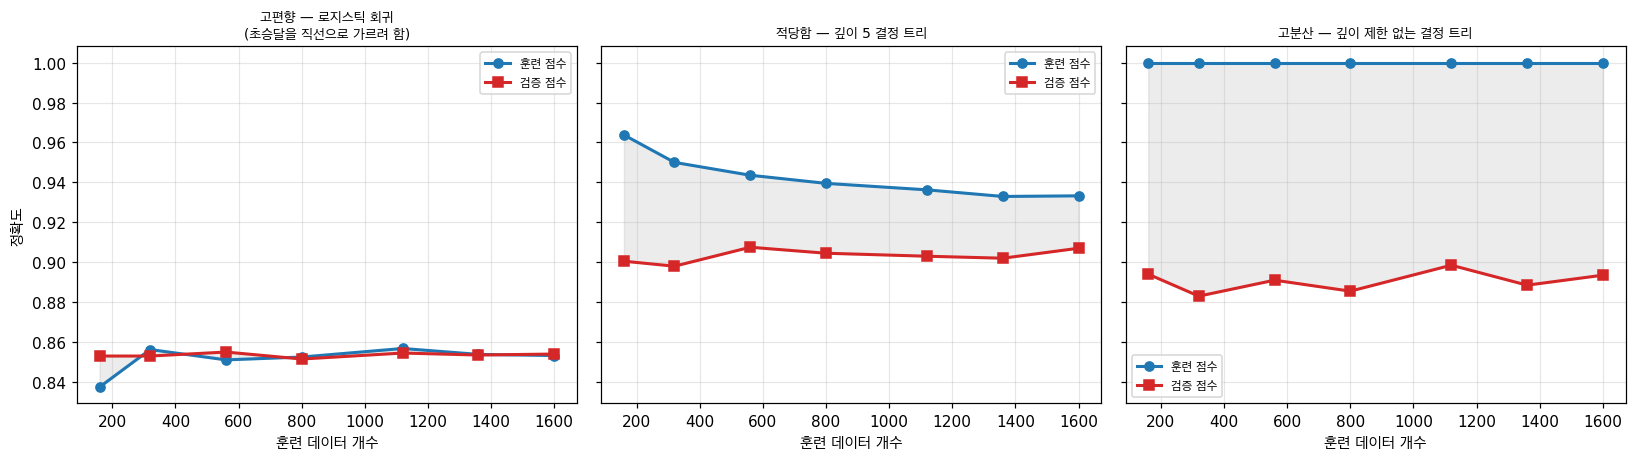

경우              최종 훈련      최종 검증       간격       후반 상승폭   처방
--------------------------------------------------------------------------
고편향            85.3%      85.4%    -0.1%         0.2%   모델을 키우세요 (데이터는 소용없음)
적당함            93.3%      90.7%     2.6%         0.3%   지금이 적당합니다
고분산           100.0%      89.4%    10.6%         0.8%   데이터를 더 모으세요 (또는 규제)

=> 왼쪽 그림(고편향): 두 곡선이 간격 -0.1%로 **거의 붙어** 있습니다.
   데이터를 절반에서 전부로 늘렸을 때 검증 점수 상승폭은 +0.2%p 뿐입니다.
   로지스틱 회귀는 직선밖에 못 긋는데 데이터는 초승달 모양이니까요.
   => **데이터를 더 모으는 건 돈 낭비입니다.** 모델을 바꿔야 합니다.

   오른쪽 그림(고분산): 훈련 100.0%인데 검증 89.4%입니다. **간격 10.6%.**
   그런데 데이터가 늘면서 검증 점수가 +0.8%p 올라가는 중입니다.
   => **데이터를 더 모으면 도움이 됩니다.** (또는 규제를 세게 하면 됩니다)

   가운데(적당함): 검증 90.7%로 셋 중 가장 높고 간격도 2.6%로 작습니다.

💡 같은 '성능이 낮다'인데 처방이 정반대입니다. 학습 곡선 없이는 알 수 없습니다.
   ⚠️ 왼쪽과 오른쪽의 최종 검증 점수 차이는 크지 않습니다 (85.4% vs 89.4%).
      **점수만 보면 둘이 비슷해 보이는데, 해야 할 일은 완전히 다릅니다.**
      이게 학습 곡선을 그려야 하는 이유입니다.


In [23]:
# ✨ 추가 — 고편향과 고분산을 나란히 그려 봅니다
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons

X곡, y곡 = make_moons(n_samples=2000, noise=0.28, random_state=0)

경우들 = [
    ("고편향 — 로지스틱 회귀\n(초승달을 직선으로 가르려 함)",
     lambda: LogisticRegression(max_iter=1000)),
    ("적당함 — 깊이 5 결정 트리",
     lambda: DecisionTreeClassifier(max_depth=5, random_state=0)),
    ("고분산 — 깊이 제한 없는 결정 트리",
     lambda: DecisionTreeClassifier(max_depth=None, random_state=0)),
]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
진단표 = []
for a_, (이름, 만들기) in zip(ax, 경우들):
    곡선 = 학습곡선(만들기, X곡, y곡)
    크기 = [c[0] for c in 곡선]
    훈련 = [c[1] for c in 곡선]
    검증 = [c[2] for c in 곡선]
    a_.plot(크기, 훈련, "o-", lw=2, c="tab:blue", label="훈련 점수")
    a_.plot(크기, 검증, "s-", lw=2, c="tab:red", label="검증 점수")
    a_.fill_between(크기, 검증, 훈련, alpha=0.15, color="gray")
    a_.set_xlabel("훈련 데이터 개수"); a_.set_title(이름, fontsize=9)
    a_.legend(fontsize=8); a_.grid(alpha=0.3)
    진단표.append((이름.split(" —")[0], 훈련[-1], 검증[-1], 훈련[-1] - 검증[-1],
                  검증[-1] - 검증[len(검증)//2]))
ax[0].set_ylabel("정확도")
plt.tight_layout(); plt.show()

print(f"{'경우':<10}{'최종 훈련':>11}{'최종 검증':>11}{'간격':>9}{'후반 상승폭':>13}   처방")
print("-" * 74)
for 이름, tr, va, 간격, 상승 in 진단표:
    if 간격 > 0.06:
        처방 = "데이터를 더 모으세요 (또는 규제)"
    elif va < 0.88:
        처방 = "모델을 키우세요 (데이터는 소용없음)"
    else:
        처방 = "지금이 적당합니다"
    print(f"{이름:<9}{tr:>11.1%}{va:>11.1%}{간격:>9.1%}{상승:>13.1%}   {처방}")

편향, 적당, 분산 = 진단표
print(f"\n=> 왼쪽 그림(고편향): 두 곡선이 간격 {편향[3]:.1%}로 **거의 붙어** 있습니다.")
print(f"   데이터를 절반에서 전부로 늘렸을 때 검증 점수 상승폭은 {편향[4]:+.1%}p 뿐입니다.")
print("   로지스틱 회귀는 직선밖에 못 긋는데 데이터는 초승달 모양이니까요.")
print("   => **데이터를 더 모으는 건 돈 낭비입니다.** 모델을 바꿔야 합니다.")
print(f"\n   오른쪽 그림(고분산): 훈련 {분산[1]:.1%}인데 검증 {분산[2]:.1%}입니다. "
      f"**간격 {분산[3]:.1%}.**")
print(f"   그런데 데이터가 늘면서 검증 점수가 {분산[4]:+.1%}p 올라가는 중입니다.")
print("   => **데이터를 더 모으면 도움이 됩니다.** (또는 규제를 세게 하면 됩니다)")
print(f"\n   가운데(적당함): 검증 {적당[2]:.1%}로 셋 중 가장 높고 간격도 {적당[3]:.1%}로 작습니다.")
print("\n💡 같은 '성능이 낮다'인데 처방이 정반대입니다. 학습 곡선 없이는 알 수 없습니다.")
print("   ⚠️ 왼쪽과 오른쪽의 최종 검증 점수 차이는 크지 않습니다"
      f" ({편향[2]:.1%} vs {분산[2]:.1%}).")
print("      **점수만 보면 둘이 비슷해 보이는데, 해야 할 일은 완전히 다릅니다.**")
print("      이게 학습 곡선을 그려야 하는 이유입니다.")

---

## 8️⃣ 검증 곡선 — 복잡도 고르기

> 📗 **원문** — "Validation Curves"
>
> 🔗 **앞 절과 이어서** — 7절이 "데이터냐 모델이냐"를 알려 줬습니다.
> "모델을 키워라"는 답이 나왔다면, **얼마나 키울까요?** 그걸 알려 주는 게 검증 곡선입니다.

### 📗 그리는 방법

**하이퍼파라미터를 바꿔 가며** 훈련 점수와 검증 점수를 그립니다.
(7절은 **데이터 크기**를 바꿨고, 여기는 **복잡도**를 바꿉니다. 그게 유일한 차이입니다.)

### 📗 읽는 방법

| 구간 | 모양 | 상태 |
| --- | --- | --- |
| **복잡도 낮음** | 둘 다 낮음 | **과소적합** |
| **적당함** | 둘 다 높고 가까움 | ✅ **여기를 고르세요** |
| **복잡도 높음** | 훈련은 계속 높은데 검증이 떨어짐 | **과적합** |

> **검증 점수가 최고인 지점**이 답입니다.

이건 1단원 6절, 2단원 8절, 4단원 5절, 6단원 3절, 7단원 3절에서 계속 봤던 그림입니다.
**이제 그걸 그리는 표준 도구에 이름을 붙이는 겁니다.**

 max_depth        훈련        검증       간격   상태
--------------------------------------------------------
         1     81.4%     81.0%     0.3%   과소적합 (둘 다 낮음)
         2     89.8%     89.0%     0.8%   과소적합 (둘 다 낮음)
         3     89.8%     89.0%     0.8%   과소적합 (둘 다 낮음)
         4     89.9%     89.1%     0.8%   과소적합 (둘 다 낮음)
         5     93.3%     90.7%     2.6%   거의 비슷 (이 정도면 써도 됩니다)
         6     94.2%     91.6%     2.6%   <- 검증 최고. 여기를 고르세요
         8     96.0%     91.1%     5.0%   거의 비슷 (이 정도면 써도 됩니다)
        10     97.8%     90.3%     7.5%   과적합 (훈련만 높음)
        14     99.6%     89.8%     9.9%   과적합 (훈련만 높음)
        20    100.0%     89.4%    10.6%   과적합 (훈련만 높음)
        30    100.0%     89.4%    10.6%   과적합 (훈련만 높음)


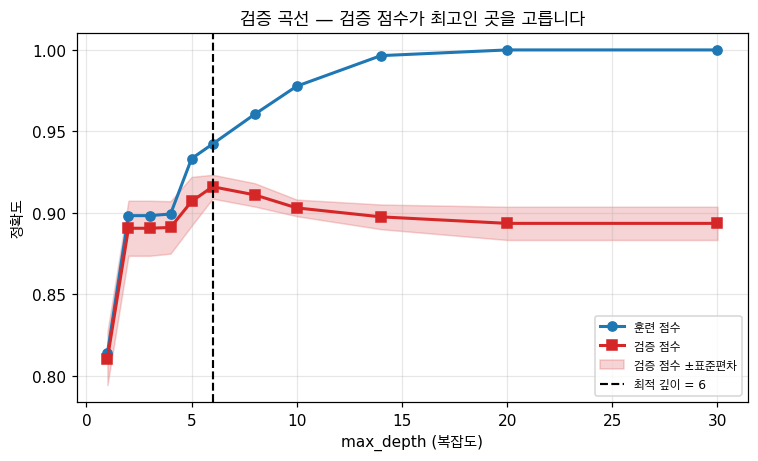


=> 깊이 6에서 검증 점수 91.6%가 최고입니다.
   더 깊게 하면 훈련 점수는 100.0%까지 올라가는데 검증은 89.4%로 떨어집니다.
   이 벌어지는 모양이 **과적합의 표준 그림**입니다.

💡 7절 학습 곡선과 8절 검증 곡선은 축만 다릅니다.
   · 학습 곡선: x축 = 데이터 개수  -> '데이터를 더 모을까?'에 답
   · 검증 곡선: x축 = 복잡도       -> '얼마나 복잡하게 할까?'에 답
   두 개를 같이 보는 게 표준 진단 절차입니다.


In [24]:
# ✨ 추가 — 검증 곡선을 직접 만듭니다
def 검증곡선(만들기, X, y, 값들, K=5, 시드=0):
    결과 = []
    for v in 값들:
        훈련점수, 검증점수 = [], []
        for 훈련칸, 검증칸 in 층화K겹(y, K=K, 시드=시드):
            m = 만들기(v).fit(X[훈련칸], y[훈련칸])
            훈련점수.append(m.score(X[훈련칸], y[훈련칸]))
            검증점수.append(m.score(X[검증칸], y[검증칸]))
        결과.append((v, float(np.mean(훈련점수)), float(np.mean(검증점수)),
                     float(np.std(검증점수))))
    return 결과

깊이들 = [1, 2, 3, 4, 5, 6, 8, 10, 14, 20, 30]
곡선 = 검증곡선(lambda d: DecisionTreeClassifier(max_depth=d, random_state=0),
               X곡, y곡, 깊이들)

최고 = max(곡선, key=lambda c: c[2])
print(f"{'max_depth':>10}{'훈련':>10}{'검증':>10}{'간격':>9}   상태")
print("-" * 56)
for v, tr, va, sd in 곡선:
    if v == 최고[0]:
        상태 = "<- 검증 최고. 여기를 고르세요"
    elif abs(va - 최고[2]) <= 0.01:
        상태 = "거의 비슷 (이 정도면 써도 됩니다)"
    elif v < 최고[0]:
        상태 = "과소적합 (둘 다 낮음)"
    else:
        상태 = "과적합 (훈련만 높음)"
    print(f"{v:>10}{tr:>10.1%}{va:>10.1%}{tr-va:>9.1%}   {상태}")

plt.figure(figsize=(7, 4.3))
plt.plot([c[0] for c in 곡선], [c[1] for c in 곡선], "o-", lw=2, c="tab:blue", label="훈련 점수")
plt.plot([c[0] for c in 곡선], [c[2] for c in 곡선], "s-", lw=2, c="tab:red", label="검증 점수")
plt.fill_between([c[0] for c in 곡선],
                 [c[2] - c[3] for c in 곡선], [c[2] + c[3] for c in 곡선],
                 alpha=0.2, color="tab:red", label="검증 점수 ±표준편차")
plt.axvline(최고[0], c="black", ls="--", lw=1.4, label=f"최적 깊이 = {최고[0]}")
plt.xlabel("max_depth (복잡도)"); plt.ylabel("정확도")
plt.title("검증 곡선 — 검증 점수가 최고인 곳을 고릅니다")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n=> 깊이 {최고[0]}에서 검증 점수 {최고[2]:.1%}가 최고입니다.")
print(f"   더 깊게 하면 훈련 점수는 {곡선[-1][1]:.1%}까지 올라가는데 검증은 {곡선[-1][2]:.1%}로 떨어집니다.")
print("   이 벌어지는 모양이 **과적합의 표준 그림**입니다.")
print("\n💡 7절 학습 곡선과 8절 검증 곡선은 축만 다릅니다.")
print("   · 학습 곡선: x축 = 데이터 개수  -> '데이터를 더 모을까?'에 답")
print("   · 검증 곡선: x축 = 복잡도       -> '얼마나 복잡하게 할까?'에 답")
print("   두 개를 같이 보는 게 표준 진단 절차입니다.")

---

## 9️⃣ 흔한 실수 다섯 가지

> 📗 **원문** — "Common Evaluation Mistakes"
>
> 🔗 **정리하는 절입니다** — 이 단원에서(그리고 8단원에서) 만난 함정을 모았습니다.

| # | 실수 | 어디서 봤나 | 막는 법 |
| --- | --- | --- | --- |
| 1 | **데이터 누출** | 2절, 8단원 3·9절 | **먼저 나누고, 그다음 전처리.** `Pipeline`을 쓰세요 |
| 2 | **클래스 불균형 무시** | 0절, 4절 | 정확도 대신 **정밀도·재현율·F1·PR 곡선** |
| 3 | **지표를 잘못 고름** | 4·6절 | 비용 구조를 보세요. 놓치면 곤란 → 재현율, 이상치 → MAE |
| 4 | **층화를 안 씀** | 3절 | 분류면 **무조건 층화** |
| 5 | **테스트를 너무 자주 봄** | 1절 | 테스트는 **딱 한 번.** 튜닝은 검증에서 |

### ⚠️ 5번이 가장 조용하고 위험합니다

> 📗 원문: "every time you look at test performance and adjust, you overfit to the test set.
> The test set is single-use."

1절에서 확인했죠. 후보를 많이 볼수록 **뽑힌 것의 검증 점수와 테스트 점수가 벌어졌습니다.**
테스트 세트로 튜닝하면 똑같은 일이 테스트 세트에서 벌어집니다.
그러면 **더 이상 어디에도 정직한 추정치가 없습니다.**

### 🧸 실무 습관

**테스트 세트를 파일째 따로 두고, 프로젝트 마지막 날까지 열지 마세요.**
그게 가장 확실한 방법입니다.

In [25]:
# ✨ 추가 — 실수 5번을 재현: 테스트 세트로 튜닝하면 무슨 일이 벌어지나
검쪽, 테쪽 = [], []
for 시드 in range(10):
    Xd, yd = 불균형데이터(시드, n=1200, 양성비율=0.5)
    X미래, y미래 = 불균형데이터(500 + 시드, n=3000, 양성비율=0.5)   # '진짜 미래'를 흉내 냅니다
    # 훈련 75% / 검증 15% / 테스트 10%
    Xtr, X나머지, ytr, y나머지 = train_test_split(Xd, yd, test_size=0.25,
                                                random_state=시드, stratify=yd)
    Xva, Xte, yva, yte = train_test_split(X나머지, y나머지, test_size=0.4,
                                          random_state=시드, stratify=y나머지)
    점수 = []
    for 깊이, 최소샘플 in 후보들:
        m = DecisionTreeClassifier(max_depth=깊이, min_samples_leaf=최소샘플,
                                   random_state=0).fit(Xtr, ytr)
        점수.append((m.score(Xva, yva), m.score(Xte, yte), m.score(X미래, y미래)))
    검으로 = max(점수, key=lambda t: t[0])       # ✅ 검증으로 고름
    테로 = max(점수, key=lambda t: t[1])         # ❌ 테스트로 고름
    검쪽.append((검으로[1], 검으로[2]))
    테쪽.append((테로[1], 테로[2]))
검쪽, 테쪽 = np.array(검쪽), np.array(테쪽)

print(f"후보 {len(후보들)}개 중에서 모델을 고릅니다. (시드 10개 평균)")
print(f"테스트 세트는 {int(1200*0.1)}개입니다.\n")
print(f"{'고르는 기준':<22}{'보고할 점수':>12}{'진짜 미래 성능':>15}{'부풀린 정도':>13}")
print("-" * 66)
print(f"{'✅ 검증 세트로 고름':<20}{검쪽[:,0].mean():>13.1%}{검쪽[:,1].mean():>15.1%}"
      f"{검쪽[:,0].mean()-검쪽[:,1].mean():>+13.1%}")
print(f"{'❌ 테스트 세트로 고름':<19}{테쪽[:,0].mean():>13.1%}{테쪽[:,1].mean():>15.1%}"
      f"{테쪽[:,0].mean()-테쪽[:,1].mean():>+13.1%}")

print("\n(✅ 쪽은 검증 세트로 고른 뒤 테스트 점수를 '한 번만' 보고했습니다)")
print("(❌ 쪽은 테스트 점수가 가장 높은 후보를 골라서 그 점수를 보고했습니다)")
print(f"\n=> ✅ 쪽의 부풀림은 {검쪽[:,0].mean()-검쪽[:,1].mean():+.1%} 입니다. "
      f"{'오히려 보수적이죠' if 검쪽[:,0].mean() < 검쪽[:,1].mean() else '거의 정직합니다'}.")
print(f"   ❌ 쪽은 {테쪽[:,0].mean()-테쪽[:,1].mean():+.1%} 로 부풀려져 있습니다.")
print("   테스트 세트에 우연히 잘 맞는 후보를 고른 것이거든요.")
print(f"\n   흥미로운 점: **진짜 미래 성능은 두 쪽이 거의 같습니다** "
      f"({검쪽[:,1].mean():.1%} vs {테쪽[:,1].mean():.1%}).")
print("   즉 테스트로 튜닝해도 **모델이 더 좋아지진 않습니다.** 보고 점수만 거짓으로 올라갑니다.")
print("   ⚠️ 그리고 이 순간 **테스트 세트를 태워 버린 겁니다.** 다시는 정직한 추정을 못 합니다.")
print("      새 데이터를 구해 오는 수밖에 없습니다.")

후보 40개 중에서 모델을 고릅니다. (시드 10개 평균)
테스트 세트는 120개입니다.

고르는 기준                      보고할 점수       진짜 미래 성능       부풀린 정도
------------------------------------------------------------------
✅ 검증 세트로 고름                 79.6%          80.8%        -1.3%
❌ 테스트 세트로 고름               82.6%          80.3%        +2.3%

(✅ 쪽은 검증 세트로 고른 뒤 테스트 점수를 '한 번만' 보고했습니다)
(❌ 쪽은 테스트 점수가 가장 높은 후보를 골라서 그 점수를 보고했습니다)

=> ✅ 쪽의 부풀림은 -1.3% 입니다. 오히려 보수적이죠.
   ❌ 쪽은 +2.3% 로 부풀려져 있습니다.
   테스트 세트에 우연히 잘 맞는 후보를 고른 것이거든요.

   흥미로운 점: **진짜 미래 성능은 두 쪽이 거의 같습니다** (80.8% vs 80.3%).
   즉 테스트로 튜닝해도 **모델이 더 좋아지진 않습니다.** 보고 점수만 거짓으로 올라갑니다.
   ⚠️ 그리고 이 순간 **테스트 세트를 태워 버린 겁니다.** 다시는 정직한 추정을 못 합니다.
      새 데이터를 구해 오는 수밖에 없습니다.


---

## 🔟 실무 — sklearn

> 📗 **원문** — "Use It"

```python
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     learning_curve, validation_curve)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, mean_absolute_error)
```

### ✅ 표준 절차 (이 순서를 외워 두세요)

1. `train_test_split(..., stratify=y)` 로 **테스트를 떼고 봉인**합니다
2. 전처리 + 모델을 **`Pipeline`으로 묶습니다** (누출 차단)
3. `GridSearchCV(..., cv=StratifiedKFold(5))` 로 **검증 안에서** 하이퍼파라미터를 고릅니다
4. `learning_curve` / `validation_curve` 로 **진단**합니다
5. 마지막에 **테스트 세트를 딱 한 번** 열어 `classification_report`를 보고합니다

In [26]:
# 📗 원문 Use It — 표준 절차를 끝까지 한 번
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import classification_report

X, y = make_moons(n_samples=2000, noise=0.28, random_state=0)

# ① 테스트를 떼고 봉인
X쓸것, X테스트, y쓸것, y테스트 = train_test_split(X, y, test_size=0.2,
                                               random_state=0, stratify=y)

# ② 전처리 + 모델을 Pipeline 으로
관 = Pipeline([("스케일", StandardScaler()),
              ("모델", DecisionTreeClassifier(random_state=0))])

# ③ 검증 안에서 하이퍼파라미터 고르기
격자 = GridSearchCV(관, {"모델__max_depth": [2, 3, 4, 5, 6, 8, 12, None],
                        "모델__min_samples_leaf": [1, 5, 20]},
                   cv=StratifiedKFold(5, shuffle=True, random_state=0),
                   scoring="f1", n_jobs=-1).fit(X쓸것, y쓸것)

print(f"가장 좋은 조합: {격자.best_params_}")
print(f"교차검증 F1  : {격자.best_score_:.4f}\n")

# ⑤ 마지막에 테스트를 딱 한 번
print("=== 최종 보고 (테스트 세트, 처음이자 마지막으로 엽니다) ===")
print(classification_report(y테스트, 격자.predict(X테스트),
                            target_names=["클래스 0", "클래스 1"], digits=3))
print(f"AUC-ROC: {roc_auc_score(y테스트, 격자.predict_proba(X테스트)[:, 1]):.4f}")

가장 좋은 조합: {'모델__max_depth': 5, '모델__min_samples_leaf': 20}
교차검증 F1  : 0.9112

=== 최종 보고 (테스트 세트, 처음이자 마지막으로 엽니다) ===
              precision    recall  f1-score   support

       클래스 0      0.937     0.885     0.910       200
       클래스 1      0.891     0.940     0.915       200

    accuracy                          0.912       400
   macro avg      0.914     0.912     0.912       400
weighted avg      0.914     0.912     0.912       400

AUC-ROC: 0.9581


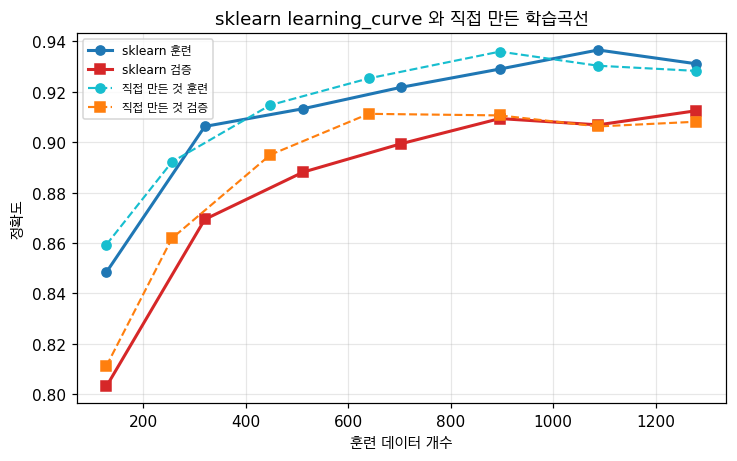

마지막 지점 비교
  sklearn    : 훈련 0.9311  검증 0.9125
  직접 만든 것 : 훈련 0.9283  검증 0.9081
=> 값이 비슷하면 같은 일을 한 겁니다.
   (sklearn은 겹마다 훈련 부분을 무작위로 고르고, 우리는 앞에서부터 잘라서 조금 다릅니다)


In [27]:
# ✨ 추가 — sklearn의 learning_curve 와 우리가 만든 것 비교
크기들, 훈련점수, 검증점수 = learning_curve(
    격자.best_estimator_, X쓸것, y쓸것,
    train_sizes=np.linspace(0.1, 1.0, 7),
    cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=-1)

내곡선 = 학습곡선(lambda: DecisionTreeClassifier(
    max_depth=격자.best_params_["모델__max_depth"],
    min_samples_leaf=격자.best_params_["모델__min_samples_leaf"],
    random_state=0), X쓸것, y쓸것)

plt.figure(figsize=(6.8, 4.3))
plt.plot(크기들, 훈련점수.mean(1), "o-", lw=2, c="tab:blue", label="sklearn 훈련")
plt.plot(크기들, 검증점수.mean(1), "s-", lw=2, c="tab:red", label="sklearn 검증")
plt.plot([c[0] for c in 내곡선], [c[1] for c in 내곡선], "o--", lw=1.4,
         c="tab:cyan", label="직접 만든 것 훈련")
plt.plot([c[0] for c in 내곡선], [c[2] for c in 내곡선], "s--", lw=1.4,
         c="tab:orange", label="직접 만든 것 검증")
plt.xlabel("훈련 데이터 개수"); plt.ylabel("정확도")
plt.title("sklearn learning_curve 와 직접 만든 학습곡선")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"마지막 지점 비교")
print(f"  sklearn    : 훈련 {훈련점수.mean(1)[-1]:.4f}  검증 {검증점수.mean(1)[-1]:.4f}")
print(f"  직접 만든 것 : 훈련 {내곡선[-1][1]:.4f}  검증 {내곡선[-1][2]:.4f}")
print("=> 값이 비슷하면 같은 일을 한 겁니다.")
print("   (sklearn은 겹마다 훈련 부분을 무작위로 고르고, 우리는 앞에서부터 잘라서 조금 다릅니다)")

---

## 1️⃣1️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **훈련 세트** | "학습용 데이터" | 모델이 파라미터를 맞추는 데 쓰는 데이터 |
| **검증 세트** | "튜닝용 데이터" | 하이퍼파라미터를 고르고 모델을 비교하는 데이터. **여러 번 봐도 됨** |
| **테스트 세트** | "최종 평가용" | **딱 한 번** 열어 최종 성능을 보고하는 데이터. 보고 나서 고치면 안 됨 |
| **K-겹 교차검증** | "여러 번 나눠 재기" | 데이터를 K조각으로 나눠 돌아가며 검증하고 K개 점수를 평균 |
| **층화** | "비율 맞추기" | 각 겹의 클래스 비율을 전체와 같게 유지. **분류면 항상 쓰세요** |
| **혼동 행렬** | "맞춘 표" | TP·FP·FN·TN 네 칸. **모든 분류 지표의 출발점** |
| **정밀도** | "정확한가" | 양성이라 한 것 중 진짜 비율. **헛짚으면 곤란할 때** |
| **재현율** | "다 찾았나" | 진짜 양성 중 잡아낸 비율. **놓치면 곤란할 때** |
| **F1** | "둘의 평균" | 정밀도와 재현율의 **조화**평균. 한쪽이 0이면 0 |
| **AUC-ROC** | "면적" | 양성 하나가 음성 하나보다 높은 점수를 받을 확률. **순위 품질** |
| **RMSE** | "평균 오차" | $\sqrt{\text{MSE}}$. 목표와 **단위가 같아** 해석이 쉬움. 큰 오차를 미워함 |
| **MAE** | "절대 오차" | 오차의 절댓값 평균. **이상치에 강함** |
| **R²** | "설명력" | 분산을 몇 % 설명했나. **0 = 평균만 답하는 것과 같음.** 음수도 가능 |
| **학습 곡선** | "데이터 늘리면?" | x축 = 데이터 개수. **데이터를 더 모을 가치가 있나**를 알려 줌 |
| **검증 곡선** | "복잡도 얼마나?" | x축 = 하이퍼파라미터. **어느 복잡도가 최적인가**를 알려 줌 |
| **데이터 누출** | "실수로 답을 봄" | 예측 시점에 없을 정보를 훈련에 쓰는 것. **경고 없이 점수만 좋아집니다** |

---

## ✅ 이 단원 요약 (7줄)

1. **정확도 하나만 보면 속습니다.** 불균형 데이터에서는 아무것도 안 배운 모델도 95%가 나옵니다.
2. **훈련/검증/테스트 셋으로 나누세요.** 검증은 여러 번, **테스트는 딱 한 번**입니다.
3. ⚠️ **누출은 경고 없이 일어납니다.** "먼저 나누고, 그다음 전처리." `Pipeline`이 이걸 강제해 줍니다.
4. **데이터가 적으면 K-겹**을 쓰세요. 한 번 나누기보다 훨씬 안정적입니다. **분류면 층화**로.
5. **AUC는 순위 품질**입니다. 임곗값과 무관하죠. 다만 불균형이 심하면 **PR 곡선**을 함께 보세요.
6. **회귀는 비용 구조로 지표를 고르세요.** MSE와 MAE는 **정반대 모델**을 고를 수 있습니다.
7. **학습 곡선으로 진단하세요.** 고편향이면 데이터를 더 모아도 소용없고, 고분산이면 도움이 됩니다.

---

## 📝 연습문제

> 📗 **원문** — "Exercises"

1. 층화 K-겹과 일반 K-겹을 불균형 데이터에서 비교하고, 겹별 점수의 분산을 재세요. → *3절에서 함*
2. 임곗값을 0.05부터 0.95까지 바꿔 가며 정밀도·재현율·F1을 그리고, F1이 최대인 임곗값을 찾으세요. → *5절에서 함*
3. 고편향 모델과 고분산 모델의 학습 곡선을 나란히 그려 진단해 보세요. → *7절에서 함*

### ✨ 추가 도전 과제

4. 5절의 `AUC` 는 사다리꼴 적분을 씁니다. 동점(같은 확률)이 많을 때 `AUC순위로`와 값이 갈리나요? 직접 만들어 확인하세요.
5. **중첩 교차검증(nested CV)**을 구현해 보세요. 바깥 겹에서 성능을 재고, 안쪽 겹에서 하이퍼파라미터를 고릅니다. `GridSearchCV`만 쓴 것보다 점수가 낮게 나오나요? 왜 그럴까요?
6. 0절의 시계열 예시에서 **자기상관을 더 강하게** 만들어 보세요 (예: 이동평균을 씌우기). 섞어 나누기와 순서대로 나누기의 격차가 얼마나 벌어지나요?
7. 6절의 MSE/MAE 실험을 **모델 학습에** 적용해 보세요. `HuberRegressor`(MAE에 가까움)와 `LinearRegression`(MSE)을 이상치 있는 데이터에 붙이면 어느 쪽이 나은가요?
8. 8단원의 특징 선택을 이 단원의 **중첩 교차검증** 안에 넣어 보세요. 8단원 9절의 누출이 정말 사라지나요?

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [scikit-learn Model Evaluation 문서](https://scikit-learn.org/stable/modules/model_evaluation.html) — 모든 지표의 정의와 사용법
- [scikit-learn Cross-validation 문서](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Learning Curves 시각화 가이드](https://scikit-learn.org/stable/modules/learning_curve.html)
- [Kaggle: Data Leakage](https://www.kaggle.com/code/alexisbcook/data-leakage) — 누출 사례 모음